# 🎮 💡 🛠️ Annotated Transformer practical

- Material adapted from [The Annotated Transformer](https://nlp.seas.harvard.edu/2018/04/03/attention.html)
- Harvard SEAS resource on teaching transformers
- Part of [LLM course](https://neelsoumya.github.io/teaching_llm_applications/) and [transformers chapter](https://neelsoumya.github.io/teaching_llm_applications/materials/transformers.html)
- 📚 📝 Also see the [Illustrated Transformer by Jay Alammar](https://jalammar.github.io/illustrated-transformer/)
- [🎥Transformers video by Grant Sanderson _3blue1brown_](https://www.youtube.com/watch?v=KJtZARuO3JY&t=177s)
- [📝Transformer tutorial by `Tensorflow` and _Francois Chollet_](https://www.tensorflow.org/text/tutorials/transformer)

# Summary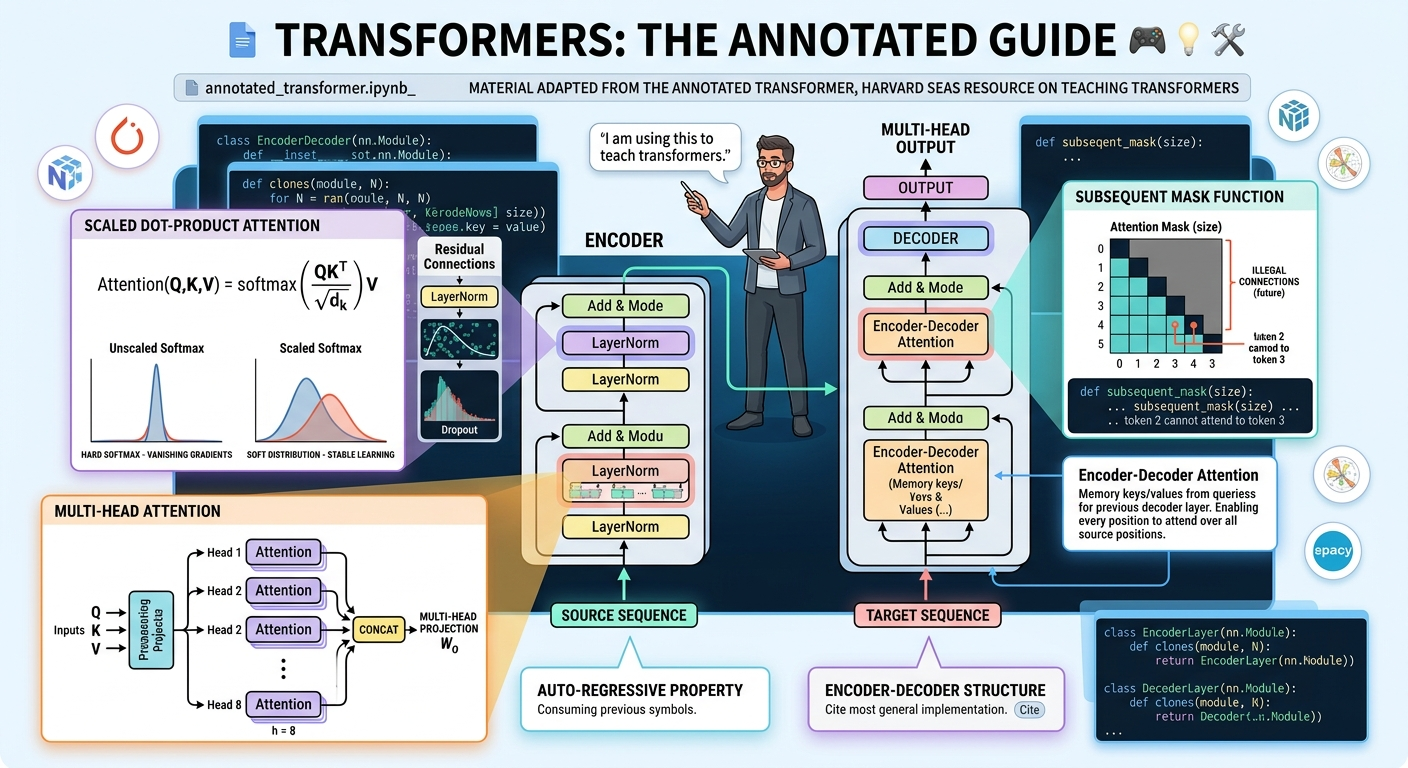

## Install packages

In [132]:
# !pip install http://download.pytorch.org/whl/cu80/torch-0.3.0.post4-cp36-cp36m-linux_x86_64.whl numpy matplotlib spacy torchtext seaborn

In [133]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import math, copy, time
from torch.autograd import Variable
import matplotlib.pyplot as plt
import seaborn
seaborn.set_context(context="talk")
%matplotlib inline

## Model Architecture

- Most competitive neural sequence transduction models have an encoder-decoder structure (cite).
- Here, the encoder maps an input sequence of symbol representations to a sequence of continuous representations
- Given z, the decoder then generates an output sequence of symbols one element at a time.
- At each step the model is auto-regressive (cite), consuming the previously generated symbols as additional input when generating the next.

In [134]:
class EncoderDecoder(nn.Module):
    """
    A standard Encoder-Decoder architecture. Base for this and many
    other models.
    """
    def __init__(self, encoder, decoder, src_embed, tgt_embed, generator):
        super(EncoderDecoder, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.src_embed = src_embed
        self.tgt_embed = tgt_embed
        self.generator = generator

    def forward(self, src, tgt, src_mask, tgt_mask):
        "Take in and process masked src and target sequences."
        return self.decode(self.encode(src, src_mask), src_mask,
                            tgt, tgt_mask)

    def encode(self, src, src_mask):
        return self.encoder(self.src_embed(src), src_mask)

    def decode(self, memory, src_mask, tgt, tgt_mask):
        return self.decoder(self.tgt_embed(tgt), memory, src_mask, tgt_mask)

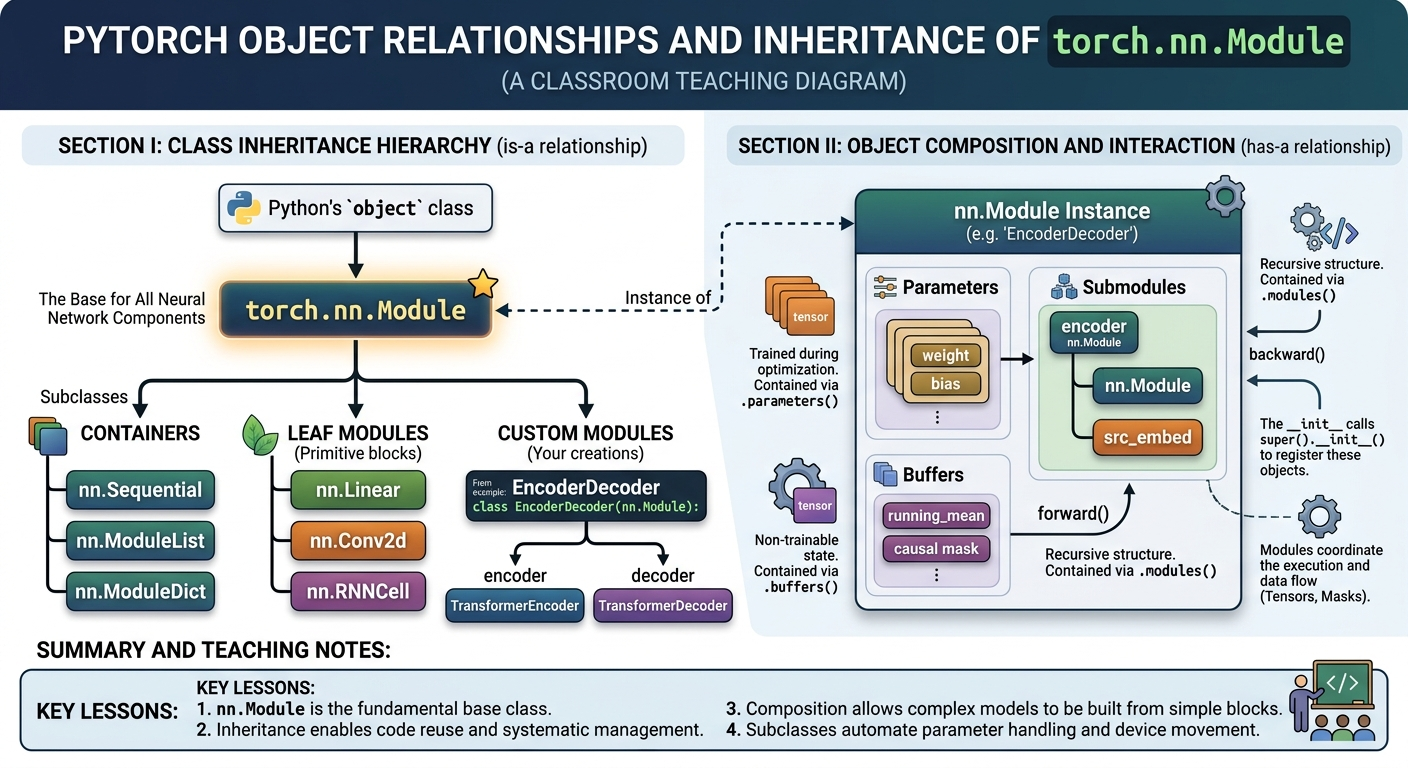

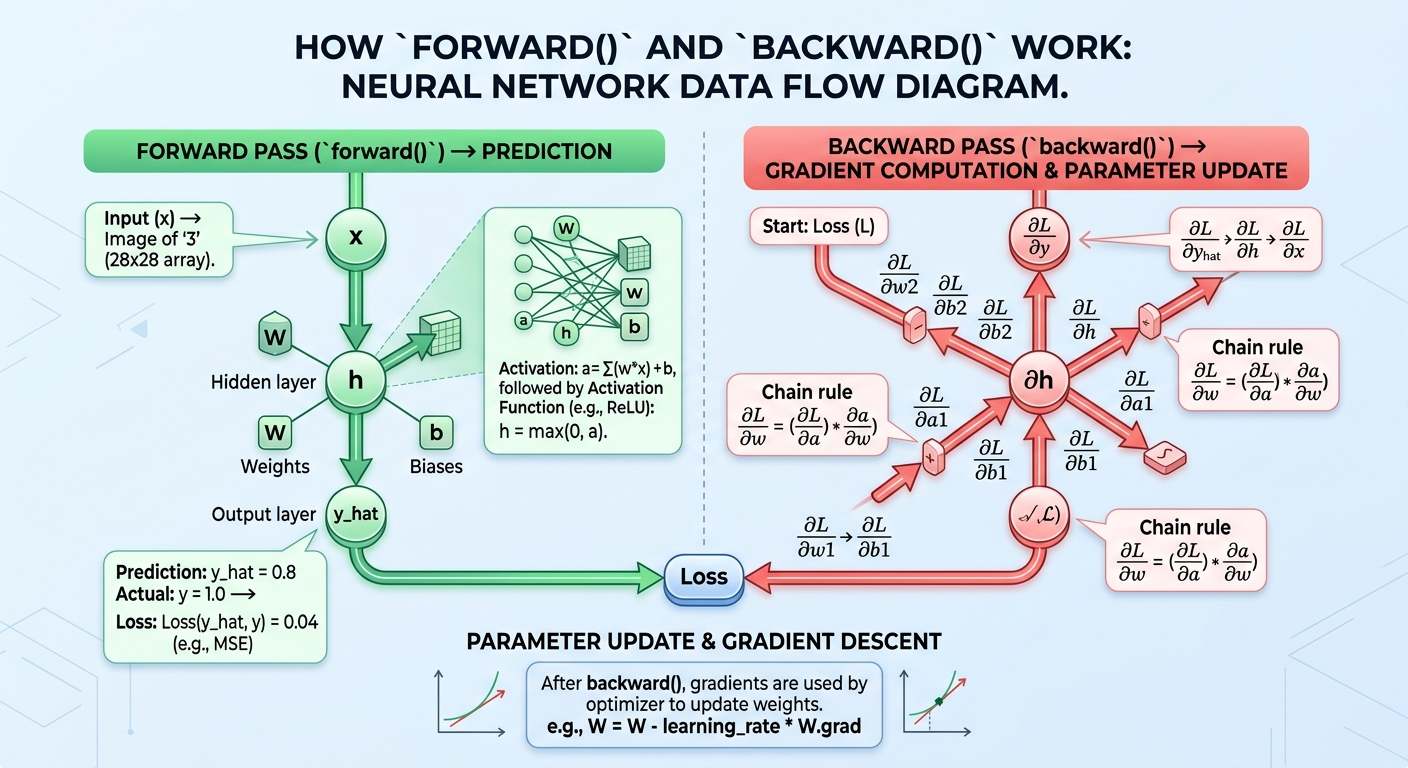

### Line-by-Line Explanation of `EncoderDecoder` Class

This code defines the `EncoderDecoder` class, which represents the overall encoder-decoder architecture commonly found in sequence-to-sequence models like the Transformer. It orchestrates the flow of data through separate encoder and decoder components.

```python
class EncoderDecoder(nn.Module):
    """
    A standard Encoder-Decoder architecture. Base for this and many
    other models.
    """
    def __init__(self, encoder, decoder, src_embed, tgt_embed, generator):
        super(EncoderDecoder, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.src_embed = src_embed
        self.tgt_embed = tgt_embed
        self.generator = generator

    def forward(self, src, tgt, src_mask, tgt_mask):
        "Take in and process masked src and target sequences."
        return self.decode(self.encode(src, src_mask), src_mask,
                            tgt, tgt_mask)

    def encode(self, src, src_mask):
        return self.encoder(self.src_embed(src), src_mask)

    def decode(self, memory, src_mask, tgt, tgt_mask):
        return self.decoder(self.tgt_embed(tgt), memory, src_mask, tgt_mask)
```

Let's break down each line and section:

1.  `class EncoderDecoder(nn.Module):`
    *   **Explanation**: This line declares the `EncoderDecoder` class, inheriting from `nn.Module`. This inheritance is essential in PyTorch for any neural network component, allowing it to manage parameters, submodules, and integrate with PyTorch's computational graph.

2.  `"""
A standard Encoder-Decoder architecture. Base for this and many
other models.
"""`
    *   **Explanation**: This is a multi-line docstring, providing a high-level overview of the class's purpose: to serve as a standard, foundational encoder-decoder structure for various models.

3.  `def __init__(self, encoder, decoder, src_embed, tgt_embed, generator):`
    *   **Explanation**: This is the constructor. It initializes an instance of `EncoderDecoder` and takes the following modules as arguments:
        *   `encoder`: The encoder module (e.g., a `TransformerEncoder`).
        *   `decoder`: The decoder module (e.g., a `TransformerDecoder`).
        *   `src_embed`: A module for embedding the source (input) sequence.
        *   `tgt_embed`: A module for embedding the target (output) sequence.
        *   `generator`: A module responsible for generating the final output probabilities (e.g., a linear layer followed by softmax).

4.  `super(EncoderDecoder, self).__init__()`
    *   **Explanation**: This calls the constructor of the parent class `nn.Module`, ensuring that all necessary base functionalities for a PyTorch module are set up.

5.  `self.encoder = encoder`
    *   **Explanation**: Stores the passed `encoder` module as an attribute of the `EncoderDecoder` instance.

6.  `self.decoder = decoder`
    *   **Explanation**: Stores the passed `decoder` module as an attribute.

7.  `self.src_embed = src_embed`
    *   **Explanation**: Stores the source embedding module. This will convert input tokens (e.g., integer IDs) into dense vector representations.

8.  `self.tgt_embed = tgt_embed`
    *   **Explanation**: Stores the target embedding module. This will convert target tokens into dense vector representations for the decoder.

9.  `self.generator = generator`
    *   **Explanation**: Stores the output generator module.

10. `def forward(self, src, tgt, src_mask, tgt_mask):`
    *   **Explanation**: This method defines the forward pass for the entire encoder-decoder model. It describes how input `src` and target `tgt` sequences, along with their respective masks, are processed.
        *   `src`: The source input sequence (e.g., input token IDs).
        *   `tgt`: The target input sequence (e.g., partially generated output token IDs).
        *   `src_mask`: A mask for the source sequence, often used for padding or to prevent attention to certain parts.
        *   `tgt_mask`: A mask for the target sequence, crucial for preventing the decoder from attending to future tokens (causal masking).

11. `"Take in and process masked src and target sequences."`
    *   **Explanation**: Docstring for the `forward` method.

12. `return self.decode(self.encode(src, src_mask), src_mask, tgt, tgt_mask)`
    *   **Explanation**: This is the core logic of the `forward` pass. It first calls `self.encode` to process the source sequence, then takes the output of the encoder and passes it, along with target-related inputs, to `self.decode`. The final output of the `decode` method is returned.

13. `def encode(self, src, src_mask):`
    *   **Explanation**: This helper method defines the encoder's specific forward pass.
        *   `src`: The raw source input.
        *   `src_mask`: The source mask.

14. `return self.encoder(self.src_embed(src), src_mask)`
    *   **Explanation**: Inside `encode`, it first embeds the `src` input using `self.src_embed` (converting tokens to vectors) and then passes these embeddings, along with the `src_mask`, to the actual `self.encoder` module. The output of the encoder (often called 'memory' or 'context' vector) is returned.

15. `def decode(self, memory, src_mask, tgt, tgt_mask):`
    *   **Explanation**: This helper method defines the decoder's specific forward pass.
        *   `memory`: The output from the encoder (the 'context').
        *   `src_mask`: The source mask (still needed for encoder-decoder attention within the decoder).
        *   `tgt`: The raw target input.
        *   `tgt_mask`: The target mask (crucial for causal attention).

16. `return self.decoder(self.tgt_embed(tgt), memory, src_mask, tgt_mask)`
    *   **Explanation**: Inside `decode`, it first embeds the `tgt` input using `self.tgt_embed`. Then, these target embeddings, the `memory` from the encoder, and both `src_mask` and `tgt_mask` are passed to the `self.decoder` module. The output of the decoder (which represents the processed target sequence at each step) is returned. This output is typically then fed to the `generator` module to produce final predictions.

In [135]:
class Generator(nn.Module):
    "Define standard linear + softmax generation step."
    def __init__(self, d_model, vocab):
        super(Generator, self).__init__()
        self.proj = nn.Linear(d_model, vocab)

    def forward(self, x):
        return F.log_softmax(self.proj(x), dim=-1)

The Transformer follows this overall architecture using stacked self-attention and point-wise, fully connected layers for both the encoder and decoder, shown in the left and right halves of Figure 1, respectively.

# PyTorch resources

- [Basics of PyTorch](https://github.com/neelsoumya/teaching_intro_pytorch)
- [Basic for ANN in PyTorch](https://github.com/neelsoumya/teaching_intro_pytorch/blob/main/03_nn.py)

# PyTorch Core Mechanics: Deep Dive into `forward()` and `backward()`

A comprehensive guide for students and instructors explaining the internal workings, data flow, dynamic graph construction, and automatic differentiation engine in PyTorch.

---

## 1. Executive Summary & Core Philosophy

In PyTorch, model training relies on two foundational, complementary operations:
1. **The Forward Pass (`forward()`)**: Transforms input tensors through layered mathematical operations to yield predictions and calculates a scalar loss value. Concurrently, PyTorch dynamically constructs a Directed Acyclic Graph (DAG) tracking all performed operations.
2. **The Backward Pass (`backward()`)**: Traverses the dynamically created computational graph in reverse (from output loss to input parameters), computing exact gradients via reverse-mode automatic differentiation (the Chain Rule) and populating tensor `.grad` attributes.

```
       FORWARD PASS (Data & Graph Building)
  Input (x)  ──────►  Layers / Modules  ──────►  Prediction (ŷ) ──────► Loss (L)
                                                                            │
                                                                            │ loss.backward()
       BACKWARD PASS (Gradient Backpropagation)                             ▼
  ∂L/∂W       ◄──────  Chain Rule  ◄──────────  Grad Engine  ◄──────────────┘
```

---

## 2. The Forward Pass (`forward()`)

### 2.1 What Happens During `forward()`?
When input data is passed through a PyTorch `nn.Module`, the model computes output values layer by layer. Beyond simple mathematical evaluation, the forward pass performs key infrastructure setup:

* **Tensor Computation**: Executes matrix multiplications, convolutions, bias additions, and non-linear activations (e.g., ReLU, Softmax).
* **Dynamic Computational Graph Construction**: For every operation involving tensors with `requires_grad=True`, PyTorch appends a node to an execution graph.
* **State & Activation Caching**: Saves intermediate values (such as pre-activation hidden states) required later for derivative calculations during the backward pass.

### 2.2 Calling Syntax: `model(x)` vs `model.forward(x)`

> **Important Teaching Note:** Always invoke modules using `model(x)` rather than calling `model.forward(x)` directly.

```python
# PREFERRED (Executes PyTorch module hooks and state tracking):
output = model(inputs)

# AVOID (Bypasses PyTorch internal hooks, profiling, and pre/post-forward handles):
output = model.forward(inputs)
```

When calling `model(inputs)`, Python calls `nn.Module.__call__()`, which handles:
1. Executing registered `forward_pre_hooks`.
2. Invoking your custom `forward()` implementation.
3. Executing registered `forward_hooks`.
4. Registering target output dependencies for backward computation.

---

## 3. The Dynamic Computational Graph (DAG)

Unlike static graph frameworks, PyTorch uses **Define-by-Run** dynamic computational graphs. The graph is built on-the-fly during the forward pass and destroyed after the backward pass.

### 3.1 Anatomy of Graph Nodes

Every tensor created by an operation carries a reference to its creator function via `grad_fn`:

* **Leaf Tensors**: User-created tensors or trainable parameters ($W$, $b$) created directly. They have `grad_fn = None` and `requires_grad = True`.
* **Intermediate Tensors**: Tensors produced by operations (e.g., $h = Wx + b$). They store a `grad_fn` point matching the operation (e.g., `<AddBackward0>`, `<MmBackward0>`).

```
  [ W (Leaf) ] ──┐
                 ├──► [ mm() ] ──► [ Tensor h ] ──► [ Relu() ] ──► [ Tensor a ] ──► Loss (L)
  [ x (Input) ] ─┘   (MmBackward)                  (ReluBackward)
```

---

## 4. The Backward Pass (`backward()`)

### 4.1 Triggering Automatic Differentiation (Autograd)
Calling `loss.backward()` initiates reverse-mode automatic differentiation starting from the scalar loss node $L$.

### 4.2 Application of the Calculus Chain Rule
The autograd engine traverses the graph backward from output to inputs. At each node, it computes local partial derivatives and multiplies them by incoming gradient signals from upstream nodes.

#### Mathematical Formulation:
For a simple multi-layer sequence $h = Wx + b$, $a = \sigma(h)$, and $L = 	ext{Loss}(a, y)$:

1. **Upstream Gradient at Output**:
   $$rac{\partial L}{\partial a}$$

2. **Gradient Through Activation $\sigma(h)$**:
   $$rac{\partial L}{\partial h} = rac{\partial L}{\partial a} \cdot \sigma'(h)$$

3. **Gradient With Respect to Weights $W$**:
   $$rac{\partial L}{\partial W} = rac{\partial L}{\partial h} \cdot x^T$$

4. **Gradient With Respect to Biases $b$**:
   $$rac{\partial L}{\partial b} = rac{\partial L}{\partial h}$$

### 4.3 Gradient Storage & Accumulation
Unlike standard assignments, PyTorch **accumulates** (adds) gradients into `.grad`:

$$	ext{tensor.grad} \leftarrow 	ext{tensor.grad} + 	ext{new\_gradient}$$

Because gradients accumulate, you must explicitly clear them before starting a new optimization iteration using `optimizer.zero_grad()`.

---

## 5. Summary Table: Forward vs. Backward

| Feature / Aspect | Forward Pass (`forward()`) | Backward Pass (`backward()`) |
| :--- | :--- | :--- |
| **Primary Goal** | Generate predictions ($\hat{y}$) & calculate Loss ($L$) | Calculate gradients ($rac{\partial L}{\partial W}$) for parameters |
| **Direction of Data** | Input $
ightarrow$ Layers $
ightarrow$ Prediction $
ightarrow$ Loss | Loss $
ightarrow$ Layers $
ightarrow$ Parameters |
| **Graph Action** | **Builds** the Dynamic DAG | **Traverses** and **Frees** the Dynamic DAG |
| **Primary PyTorch Trigger** | `model(x)` / `criterion(y_hat, y)` | `loss.backward()` |
| **Underlying Engine** | Python module execution & C++ Catenation | C++ `torch::autograd` Engine |
| **Memory Impact** | Allocates tensor activations in VRAM/RAM | Frees intermediate activation graph memory |
| **Parameter Impact** | Parameters remain unchanged | Gradients populate `param.grad` (Parameters not updated yet) |

---

## 6. The Complete Training Step Workflow

A standard training loop brings `forward()`, `backward()`, and parameter updating together in a precise 4-step cadence:

```python
import torch
import torch.nn as nn
import torch.optim as optim

# Sample Model Definition
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h = self.fc1(x)
        a = self.relu(h)
        out = self.fc2(a)
        return out

# Instantiate Model, Loss Function, and Optimizer
model = SimpleMLP(input_dim=10, hidden_dim=32, output_dim=1)
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Dummy Input and Target
inputs = torch.randn(8, 10)
targets = torch.randn(8, 1)

# --- SINGLE TRAINING ITERATION ---

# STEP 1: Clear previous step gradients
# Sets all param.grad values to None/0 to prevent unwanted gradient accumulation
optimizer.zero_grad()

# STEP 2: Forward Pass
# Evaluates network layers, caches intermediate states, constructs dynamic graph
predictions = model(inputs)
loss = criterion(predictions, targets)

# STEP 3: Backward Pass
# Traverses graph from loss back to parameters, computes derivatives via Chain Rule
loss.backward()

# STEP 4: Optimizer Step (Parameter Update)
# Adjusts parameters using stored gradients: W = W - lr * W.grad
optimizer.step()
```

---

## 7. Common Pitfalls & Instructor FAQ

### Q1: Why do we call `optimizer.zero_grad()` before `loss.backward()`?
> **Answer:** PyTorch accumulates gradients into `.grad` by default. If `zero_grad()` is omitted, gradients from the current batch will add to gradients from previous batches, leading to incorrect gradient magnitudes and divergent training.

### Q2: What happens if I call `loss.backward()` twice?
> **Answer:** PyTorch frees the computational graph immediately after `backward()` executes to conserve memory. Calling `backward()` a second time will raise a `RuntimeError: Trying to backward through the graph a second time...` unless `loss.backward(retain_graph=True)` was specified.

### Q3: Why does `loss.backward()` not update model weights?
> **Answer:** Decoupling gradient calculation from parameter updates provides modularity. `loss.backward()` strictly computes derivatives and stores them in `param.grad`. The `optimizer.step()` function uses these stored gradients according to a specific optimization algorithm (SGD, Adam, AdamW, etc.).


## Encoder and decoders

### Encoder

In [136]:
def clones(module, N):
    "Produce N identical layers."
    return nn.ModuleList([copy.deepcopy(module) for _ in range(N)])

class Encoder(nn.Module):
    "Core encoder is a stack of N layers"
    def __init__(self, layer, N):
        super(Encoder, self).__init__()
        self.layers = clones(layer, N)
        self.norm = LayerNorm(layer.size)

    def forward(self, x, mask):
        "Pass the input (and mask) through each layer in turn."
        for layer in self.layers:
            x = layer(x, mask)
        return self.norm(x)

We employ a residual connection (cite) around each of the two sub-layers, followed by layer normalization (cite).



In [137]:
class LayerNorm(nn.Module):
    "Construct a layernorm module (See citation for details)."
    def __init__(self, features, eps=1e-6):
        super(LayerNorm, self).__init__()
        self.a_2 = nn.Parameter(torch.ones(features))
        self.b_2 = nn.Parameter(torch.zeros(features))
        self.eps = eps

    def forward(self, x):
        mean = x.mean(-1, keepdim=True)
        std = x.std(-1, keepdim=True)
        return self.a_2 * (x - mean) / (std + self.eps) + self.b_2


- That is, the output of each sub-layer is
 where  is the function implemented by the sub-layer itself. We apply dropout (cite) to the output of each sub-layer, before it is added to the sub-layer input and normalized.

- To facilitate these residual connections, all sub-layers in the model, as well as the embedding layers, produce outputs of dimension
d model = 512
.

In [138]:
class SublayerConnection(nn.Module):
    """
    A residual connection followed by a layer norm.
    Note for code simplicity the norm is first as opposed to last.
    """
    def __init__(self, size, dropout):
        super(SublayerConnection, self).__init__()
        self.norm = LayerNorm(size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, sublayer):
        "Apply residual connection to any sublayer with the same size."
        return x + self.dropout(sublayer(self.norm(x)))


Each layer has two sub-layers. The first is a multi-head self-attention mechanism, and the second is a simple, position-wise fully connected feed- forward network.



In [139]:
class EncoderLayer(nn.Module):
    "Encoder is made up of self-attn and feed forward (defined below)"
    def __init__(self, size, self_attn, feed_forward, dropout):
        super(EncoderLayer, self).__init__()
        self.self_attn = self_attn
        self.feed_forward = feed_forward
        self.sublayer = clones(SublayerConnection(size, dropout), 2)
        self.size = size

    def forward(self, x, mask):
        "Follow Figure 1 (left) for connections."
        x = self.sublayer[0](x, lambda x: self.self_attn(x, x, x, mask))
        return self.sublayer[1](x, self.feed_forward)


## Decoder

- The decoder is also composed of a stack of $N$ = 6 identical layers


In [140]:
class Decoder(nn.Module):
    "Generic N layer decoder with masking."
    def __init__(self, layer, N):
        super(Decoder, self).__init__()
        self.layers = clones(layer, N)
        self.norm = LayerNorm(layer.size)

    def forward(self, x, memory, src_mask, tgt_mask):
        for layer in self.layers:
            x = layer(x, memory, src_mask, tgt_mask)
        return self.norm(x)

- In addition to the two sub-layers in each encoder layer, the decoder inserts a third sub-layer, which performs multi-head attention over the output of the encoder stack. Similar to the encoder, we employ residual connections around each of the sub-layers, followed by layer normalization.


In [141]:
class DecoderLayer(nn.Module):
    "Decoder is made of self-attn, src-attn, and feed forward (defined below)"
    def __init__(self, size, self_attn, src_attn, feed_forward, dropout):
        super(DecoderLayer, self).__init__()
        self.size = size
        self.self_attn = self_attn
        self.src_attn = src_attn
        self.feed_forward = feed_forward
        self.sublayer = clones(SublayerConnection(size, dropout), 3)

    def forward(self, x, memory, src_mask, tgt_mask):
        "Follow Figure 1 (right) for connections."
        m = memory
        x = self.sublayer[0](x, lambda x: self.self_attn(x, x, x, tgt_mask))
        x = self.sublayer[1](x, lambda x: self.src_attn(x, m, m, src_mask))
        return self.sublayer[2](x, self.feed_forward)

- We also modify the self-attention sub-layer in the decoder stack to prevent positions from attending to subsequent positions. This masking, combined with fact that the output embeddings are offset by one position, ensures that the predictions for position  can depend only on the known outputs at positions less than


### `subsequent_mask` function:

*   **`def subsequent_mask(size):`**: This line defines a Python function called `subsequent_mask` that takes one argument, `size`. This function is designed to create a triangular mask, often used in Transformer models to prevent attention to future positions in a sequence.

*   **`"Mask out subsequent positions."`**: This is a docstring, a brief explanation of what the function does.

*   **`attn_shape = (1, size, size)`**: This creates a tuple `attn_shape` which defines the dimensions of the attention mask. It's typically `(batch_size, sequence_length, sequence_length)`. Here, `1` is used as a placeholder for the batch size, and `size` represents the sequence length for both the query and key dimensions of the attention matrix.

*   **`subsequent_mask = np.triu(np.ones(attn_shape), k=1).astype('uint8')`**: This is the core of the mask creation:
    *   `np.ones(attn_shape)`: Creates a 3D NumPy array filled with ones, with the shape defined by `attn_shape` (e.g., if `size` is 5, it would be a 1x5x5 array of ones).
    *   `np.triu(..., k=1)`: This function extracts the upper triangular part of the array, setting all other elements to zero. The `k=1` argument means that the main diagonal *and* everything below it is set to zero. This effectively masks out positions that are equal to or come *after* the current position. For example, in a 5x5 matrix, the element at (0,0) would be 1, but (0,1), (0,2) etc. would be 0, effectively preventing the first token from attending to itself or any subsequent tokens.
    *   `.astype('uint8')`: Converts the data type of the NumPy array to `uint8` (unsigned 8-bit integer).

*   **`return torch.from_numpy(subsequent_mask) == 0`**: This line converts the NumPy mask into a PyTorch tensor and inverts its boolean values:
    *   `torch.from_numpy(subsequent_mask)`: Converts the NumPy array `subsequent_mask` into a PyTorch tensor.
    *   `== 0`: This performs an element-wise comparison. Since `np.triu(..., k=1)` set the lower triangle and diagonal to zeros and the upper triangle to ones, this comparison will result in `True` for the positions that were originally `0` (which are the positions we *want* to allow attention to, i.e., previous and current tokens if `k=0` was used, but here it's `k=1`, so only previous tokens) and `False` for the positions that were `1` (which are the subsequent positions we want to mask out). This creates a boolean mask where `False` typically indicates positions that should be ignored or masked

In [142]:
def subsequent_mask(size):
    "Mask out subsequent positions."
    attn_shape = (1, size, size)
    subsequent_mask = np.triu(np.ones(attn_shape), k=1).astype('uint8')
    return torch.from_numpy(subsequent_mask) == 0



An attention function can be described as mapping a query and a set of key-value pairs to an output, where the query, keys, values, and output are all vectors. The output is computed as a weighted sum of the values, where the weight assigned to each value is computed by a compatibility function of the query with the corresponding key.

We call our particular attention “Scaled Dot-Product Attention”. The input consists of queries and keys of dimension $d_k$, and values of dimension $d_v$. We compute the dot products of the query with all keys, divide each by $\sqrt{d_k}$, and apply a softmax function to obtain the weights on the values.

In practice, we compute the attention function on a set of queries simultaneously, packed together into a matrix $Q$. The keys and values are also packed together into matrices $K$ and $V$. We compute the matrix of outputs as:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

When we say "in practice, we compute the attention function on a set of queries simultaneously," it means that instead of processing one query at a time, we group multiple queries together into a single matrix. This is a common optimization in deep learning to leverage matrix multiplication capabilities of hardware like GPUs.

Here's a breakdown of the components and the formula:

*   **Queries, Keys, and Values as Matrices ($Q, K, V$)**:
    *   Instead of individual vectors for a single query, key, or value, we now have matrices where each row represents a distinct query, key, or value vector from a sequence. For example, if you have a sequence of length `L` and each vector has dimension `d_k`, then $Q$ would be an `L x d_k` matrix. Similarly, $K$ would be `L x d_k` and $V$ would be `L x d_v`.

*   **The Formula: $\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$**

    1.  **$QK^T$ (Query-Key Dot Product Scores)**:
        *   This is the core of the compatibility function. The matrix multiplication of $Q$ (queries) and $K^T$ (transpose of keys) results in a score matrix. If $Q$ is `(batch_size, num_queries, d_k)` and $K$ is `(batch_size, num_keys, d_k)`, then $K^T$ is `(batch_size, d_k, num_keys)`. The product $QK^T$ will have dimensions `(batch_size, num_queries, num_keys)`. Each element $(i, j)$ in this resulting matrix represents the dot product similarity between the $i$-th query and the $j$-th key.

    2.  **Scaling by $\frac{1}{\sqrt{d_k}}$**:
        *   The dot products can grow large in magnitude as the dimension $d_k$ increases, pushing the softmax function into regions where it has extremely small gradients, which can hinder training. Dividing by the square root of $d_k$ (the dimension of the keys) helps to counteract this effect, keeping the variance of the dot products more consistent.

    3.  **$\text{softmax}(\dots)$ (Obtaining Attention Weights)**:
        *   The softmax function is applied row-wise to the scaled score matrix. This normalizes the scores for each query such that they sum to 1. The result is a matrix of attention weights, where each row indicates how much attention a particular query should pay to each of the keys.

    4.  **Multiplying by $V$ (Weighted Sum of Values)**:
        *   Finally, this matrix of attention weights is multiplied by the value matrix $V$. If the attention weights matrix is `(batch_size, num_queries, num_keys)` and $V$ is `(batch_size, num_keys, d_v)`, the result is an output matrix of dimensions `(batch_size, num_queries, d_v)`. Each row in this output matrix is a weighted sum of the value vectors, where the weights are determined by the attention mechanism. This effectively means that for each query, we get an output vector that is a combination of the input values, weighted by their relevance to that specific query.

In [143]:
def attention(query, key, value, mask=None, dropout=None):
    "Compute 'Scaled Dot Product Attention'"
    d_k = query.size(-1)
    scores = torch.matmul(query, key.transpose(-2, -1)) \
             / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)
    p_attn = F.softmax(scores, dim = -1)
    if dropout is not None:
        p_attn = dropout(p_attn)
    return torch.matmul(p_attn, value), p_attn


The two most commonly used attention functions are additive attention (cite), and dot-product (multiplicative) attention. Dot-product attention is identical to our algorithm, except for the scaling factor of $\frac{1}{\sqrt{d_k}}$. Additive attention computes the compatibility function using a feed-forward network with a single hidden layer. While the two are similar in theoretical complexity, dot-product attention is much faster and more space-efficient in practice, since it can be implemented using highly optimized matrix multiplication code.

While for small values of $d_k$ the two mechanisms perform similarly, additive attention outperforms dot product attention without scaling for larger values of $d_k$ (cite). We suspect that for large values of $d_k$, the dot products grow large in magnitude, pushing the softmax function into regions where it has extremely small gradients (To illustrate why the dot products get large, assume that the components of $q$ and $k$ are independent random variables with mean $0$ and variance $1$. Then their dot product, $q \cdot k = \sum_{i=1}^{d_k} q_i k_i$, has mean $0$ and variance $d_k$). To counteract this effect, we scale the dot products by $\frac{1}{\sqrt{d_k}}$.

### Explanation of the Demonstration:

This Python code simulates the dot product behavior for varying dimensions ($d_k$):

1.  **Vector Generation**: For each `d_k` value, it creates `num_samples` pairs of vectors, `q` and `k`. Each component of these vectors is sampled from a standard normal distribution (mean 0, variance 1), mimicking the assumption made in the text.

2.  **Unscaled Dot Product**: It calculates the dot product for each pair of `q` and `k` vectors. As predicted, the mean of the dot products stays close to 0, but their standard deviation (and thus the magnitude) increases with $d_k$. This is because the sum of $d_k$ independent random variables (each $q_i k_i$ has variance 1 if $q_i, k_i$ have variance 1) has a variance of $d_k$. The standard deviation is $\sqrt{d_k}$.

3.  **Scaled Dot Product**: It then divides each dot product by $\sqrt{d_k}$. You will observe that both the mean and standard deviation of these *scaled* dot products remain relatively constant (around 0 and 1, respectively), regardless of $d_k$. This demonstrates how scaling effectively stabilizes the variance of the dot products.

**Visual Interpretation**: The plots clearly show the divergence of unscaled dot product magnitudes as $d_k$ increases, while the scaled dot products remain within a much narrower and stable range. This stability is crucial for the softmax function, as extremely large or small inputs can lead to vanishing gradients during training.

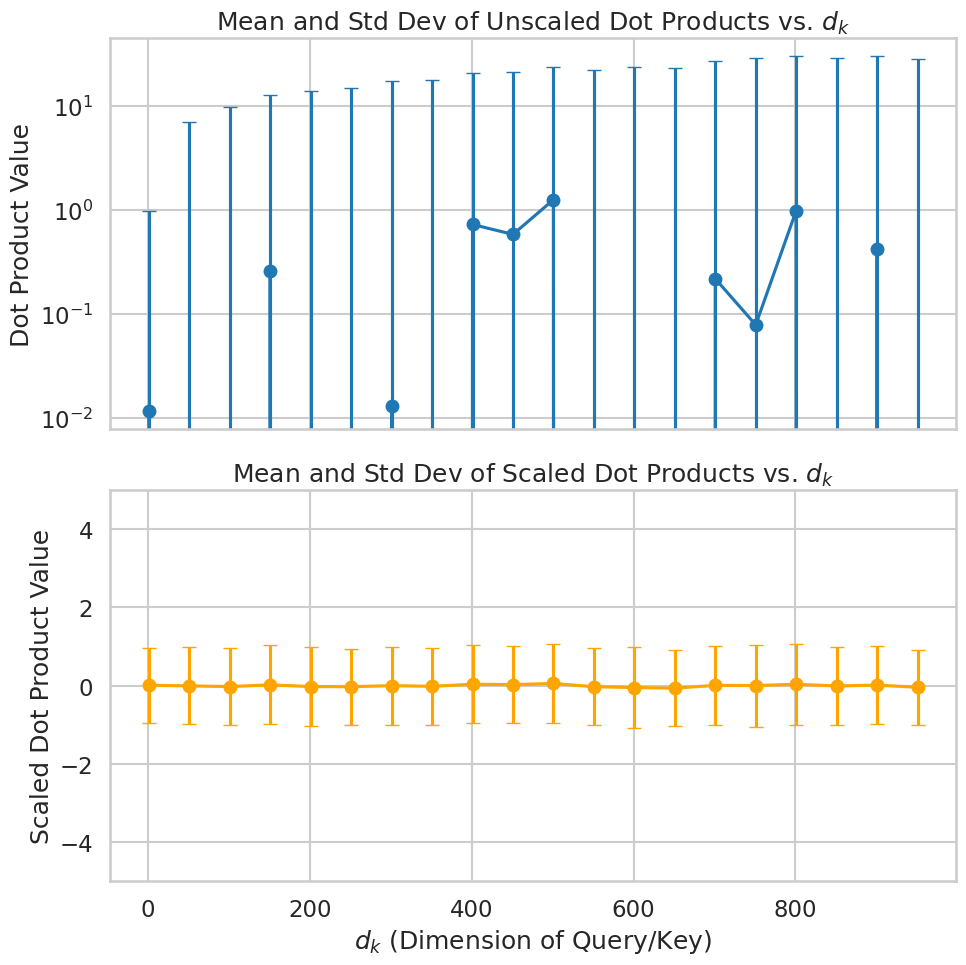

In [144]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import math # Added this line

sns.set_style("whitegrid")

def demonstrate_dot_product_scaling(max_dk=1000, num_samples=1000):
    dk_values = list(range(1, max_dk + 1, 50))
    unscaled_dot_products_mean = []
    unscaled_dot_products_std = []
    scaled_dot_products_mean = []
    scaled_dot_products_std = []

    for dk in dk_values:
        # Generate q and k components with mean 0 and variance 1
        # For simplicity, using torch.randn which produces samples from N(0, 1)
        q = torch.randn(num_samples, dk)
        k = torch.randn(num_samples, dk)

        # Calculate dot product: q * k sum over dk dimension
        # torch.sum(q * k, dim=1) gives a vector of dot products for each sample
        dot_products = torch.sum(q * k, dim=1)
        unscaled_dot_products_mean.append(torch.mean(dot_products).item())
        unscaled_dot_products_std.append(torch.std(dot_products).item())

        # Apply scaling
        scaled_dot_products = dot_products / math.sqrt(dk)
        scaled_dot_products_mean.append(torch.mean(scaled_dot_products).item())
        scaled_dot_products_std.append(torch.std(scaled_dot_products).item())

    fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

    # Plot for unscaled dot products
    axes[0].errorbar(dk_values, unscaled_dot_products_mean, yerr=unscaled_dot_products_std, fmt='-o', capsize=5)
    axes[0].set_title('Mean and Std Dev of Unscaled Dot Products vs. $d_k$')
    axes[0].set_ylabel('Dot Product Value')
    axes[0].set_yscale('log') # Use log scale to better show the increase
    axes[0].grid(True)

    # Plot for scaled dot products
    axes[1].errorbar(dk_values, scaled_dot_products_mean, yerr=scaled_dot_products_std, fmt='-o', capsize=5, color='orange')
    axes[1].set_title('Mean and Std Dev of Scaled Dot Products vs. $d_k$')
    axes[1].set_xlabel('$d_k$ (Dimension of Query/Key)')
    axes[1].set_ylabel('Scaled Dot Product Value')
    axes[1].grid(True)
    axes[1].set_ylim([-5, 5]) # Keep y-axis consistent for scaled values

    plt.tight_layout()
    plt.show()

# Run the demonstration
demonstrate_dot_product_scaling()


### Impact on Softmax Output Distribution:

The plots above demonstrate the effect of scaling on the softmax output probabilities for different values of $d_k$ (the dimension of query/key vectors).

*   **Unscaled Softmax (Red Plots)**:
    *   For small $d_k$ (e.g., $d_k=1$), the distribution of softmax probabilities might be relatively spread out.
    *   However, as $d_k$ increases (e.g., $d_k=64, 512$), the unscaled dot products become larger in magnitude. This pushes the softmax function to produce highly peaked distributions, where one probability is very close to 1 and all others are very close to 0. This is often referred to as a "hard" softmax. In a training scenario, such hard distributions result in extremely small gradients for most of the output, making learning very slow or difficult (vanishing gradients).

*   **Scaled Softmax (Blue Plots)**:
    *   When the dot products are scaled by $\frac{1}{\sqrt{d_k}}$, the magnitudes are kept in a more controlled range.
    *   Consequently, the softmax function produces a "softer" and more distributed set of probabilities, even for larger $d_k$. This means that the model can attend to a wider range of keys, and the gradients for the softmax output will be more stable and less prone to vanishing, facilitating effective learning.

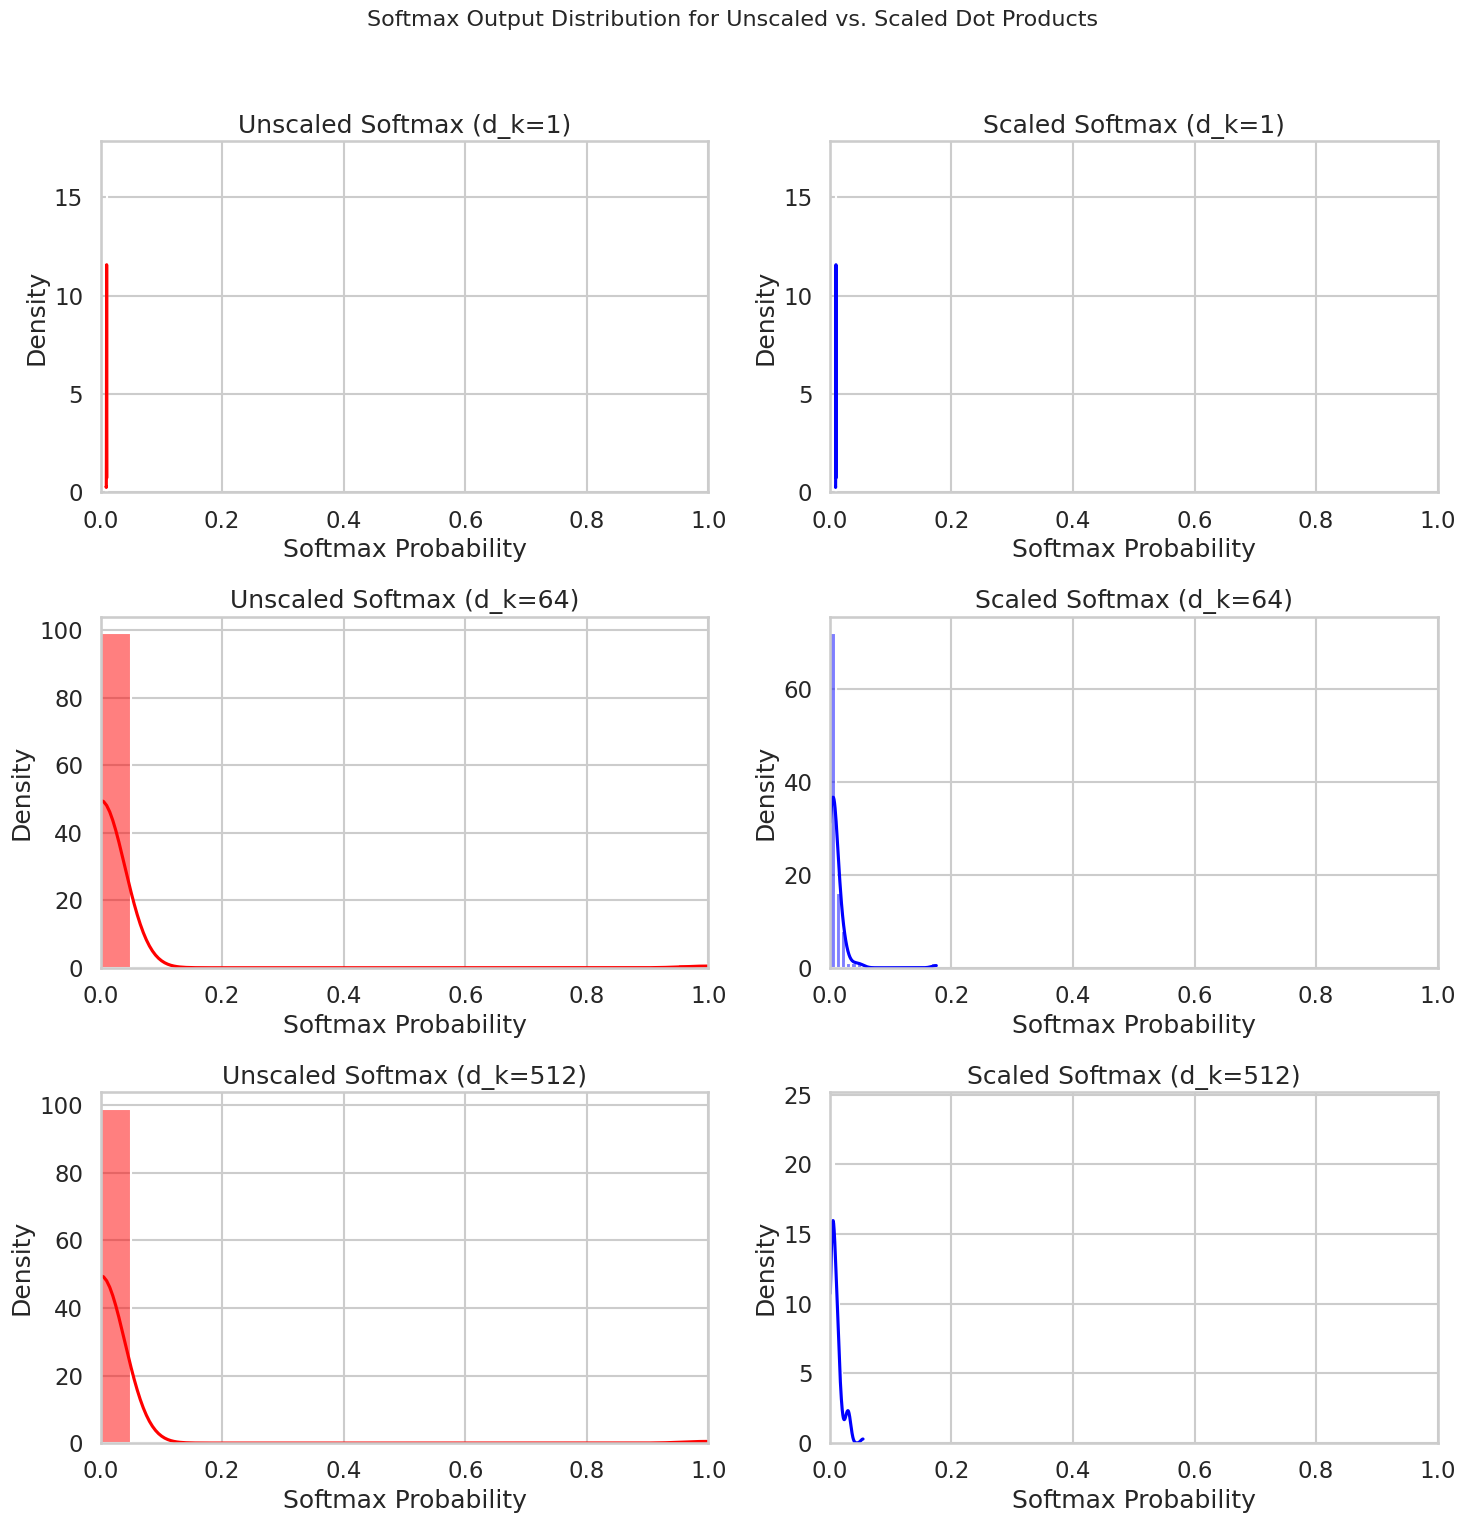

In [145]:
def plot_softmax_distribution(d_k_list=[1, 64, 512]):
    fig, axes = plt.subplots(len(d_k_list), 2, figsize=(15, 5 * len(d_k_list)))
    fig.suptitle('Softmax Output Distribution for Unscaled vs. Scaled Dot Products', fontsize=16, y=1.02)

    for i, dk in enumerate(d_k_list):
        # Generate a single query and a set of keys
        q = torch.randn(1, dk) # Single query vector
        k = torch.randn(100, dk) # 100 key vectors

        # Unscaled dot products
        unscaled_scores = torch.matmul(q, k.transpose(-2, -1)).squeeze(0) # Shape (100,)
        unscaled_softmax = F.softmax(unscaled_scores, dim=-1)

        # Scaled dot products
        scaled_scores = unscaled_scores / math.sqrt(dk)
        scaled_softmax = F.softmax(scaled_scores, dim=-1)

        # Plot unscaled softmax distribution
        sns.histplot(unscaled_softmax.numpy(), ax=axes[i, 0], kde=True, bins=20, color='red')
        axes[i, 0].set_title(f'Unscaled Softmax (d_k={dk})')
        axes[i, 0].set_xlabel('Softmax Probability')
        axes[i, 0].set_ylabel('Density')
        axes[i, 0].set_xlim([0, 1])

        # Plot scaled softmax distribution
        sns.histplot(scaled_softmax.numpy(), ax=axes[i, 1], kde=True, bins=20, color='blue')
        axes[i, 1].set_title(f'Scaled Softmax (d_k={dk})')
        axes[i, 1].set_xlabel('Softmax Probability')
        axes[i, 1].set_ylabel('Density')
        axes[i, 1].set_xlim([0, 1])

    plt.tight_layout()
    plt.show()

plot_softmax_distribution()


## Multi head attention

Multi-head attention allows the model to jointly attend to information from different representation subspaces at different positions. With a single attention head, averaging inhibits this.

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, ..., \text{head}_h)W^O$$

where

$$\text{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)$$

Where the projections are parameter matrices $W_i^Q \in \mathbb{R}^{d_{\text{model}} \times d_k}$, $W_i^K \in \mathbb{R}^{d_{\text{model}} \times d_k}$, $W_i^V \in \mathbb{R}^{d_{\text{model}} \times d_v}$ and $W^O \in \mathbb{R}^{hd_v \times d_{\text{model}}}$. In this work we employ $h = 8$ parallel attention layers, or heads. For each of these we use $d_k = d_v = d_{\text{model}}/h = 64$. Due to the reduced dimension of each head, the total computational cost is similar to that of single-head attention with full dimensionality.

### Understanding Multi-head Attention in Detail

Multi-head Attention is a crucial component of the Transformer model that allows it to capture different aspects of the input sequence simultaneously. Instead of performing a single attention function, it performs several attention functions in parallel. This enables the model to jointly attend to information from different representation subspaces at different positions.

Let's break down the components:

1.  **Multiple "Heads" (Parallel Attention Mechanisms)**:
    *   The core idea is to apply the `Attention` function (which we discussed earlier, Scaled Dot-Product Attention) `h` times in parallel. Each of these parallel operations is called an "attention head" (`head_i`).
    *   Each head learns to focus on different parts of the input sequence, effectively capturing diverse relationships and patterns.

2.  **Linear Projections for Each Head**:
    *   Before applying the attention function in each head, the input Query ($Q$), Key ($K$), and Value ($V$) matrices are first linearly projected. This means they are multiplied by learned weight matrices unique to each head.
    *   For the $i$-th head, we have projection matrices:
        *   $W_i^Q \in \mathbb{R}^{d_{\text{model}} \times d_k}$: Transforms the original Query to a query specific for head $i$.
        *   $W_i^K \in \mathbb{R}^{d_{\text{model}} \times d_k}$: Transforms the original Key to a key specific for head $i$.
        *   $W_i^V \in \mathbb{R}^{d_{\text{model}} \times d_v}$: Transforms the original Value to a value specific for head $i$.
    *   These projections allow each head to learn different linear transformations of the input, mapping them into different "representation subspaces." This is why each head can focus on different kinds of information.

    So, the input to each head's attention function becomes $QW_i^Q$, $KW_i^K$, and $VW_i^V$, not just $Q, K, V$ directly.

3.  **Individual Attention Calculation (`head_i`)**:
    *   Each `head_i` then computes the Scaled Dot-Product Attention using its specific projected Query, Key, and Value matrices:
        $$\text{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V) = \text{softmax}\left(\frac{(QW_i^Q)(KW_i^K)^T}{\sqrt{d_k}}\right)(VW_i^V)$$
    *   This results in `h` different output matrices, each capturing a different "aspect" of the attention.

4.  **Concatenation (`Concat`)**:
    *   Once all `h` attention heads have produced their outputs (`head_1, ..., head_h`), these outputs are concatenated (joined side-by-side) along their feature dimension.
    *   If each `head_i` has an output dimension of $d_v$, then concatenating `h` such heads will result in a matrix with an output dimension of $h \times d_v$.

5.  **Final Linear Projection ($W^O$)**:
    *   The concatenated output from all heads is then multiplied by another learned weight matrix, $W^O \in \mathbb{R}^{hd_v \times d_{\text{model}}}$.
    *   This final linear projection combines the information from all `h` attention heads into a single output that has the desired dimension of $d_{\text{model}}$ (the same dimension as the input to the Multi-head Attention layer).

    The full formula is:
    $$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, ..., \text{head}_h)W^O$$

### Example Parameters (as used in the original paper):

*   **Number of Heads ($h$)**: In the original Transformer paper, $h = 8$ parallel attention layers are used.
*   **Dimension of Keys and Values per Head ($d_k, d_v$)**: For each head, the dimension of the projected keys ($d_k$) and values ($d_v$) is set to $d_{\text{model}}/h = 512/8 = 64$.

### Why Reduced Dimension per Head?

The total computational cost of Multi-head Attention is similar to that of single-head attention with the full $d_{\text{model}}$ dimensionality because the dimensions of $d_k$ and $d_v$ are reduced for each head. This means we are performing $h$ smaller attention calculations in parallel, rather than one large one, allowing the model to gain richer representations without significantly increasing computational expense.

### Conceptual Diagram for Multi-head Attention

To visualize Multi-head Attention, imagine a flow from left to right, starting with your input Query, Key, and Value matrices, and ending with the combined output.

Here's a breakdown of the key sections and elements you'd want to include:

---

#### **Section 1: Input Projections**

*   **Inputs (Left Side):**
    *   Draw three large boxes labeled **Q (Query)**, **K (Key)**, and **V (Value)**. These represent the initial input matrices to the Multi-head Attention layer. Add arrows coming out of these.

*   **Parallel Linear Projections (for each Head):**
    *   From each of Q, K, and V, draw `h` parallel lines branching out. Each branch goes to a set of three smaller boxes representing the linear projection for a specific head. For example, for `Head 1`:
        *   From Q, draw an arrow to a box: **Linear Projection $W_1^Q$**
        *   From K, draw an arrow to a box: **Linear Projection $W_1^K$**
        *   From V, draw an arrow to a box: **Linear Projection $W_1^V$**
    *   Repeat this for `Head 2`, ..., up to `Head h`, each with its own $W_i^Q, W_i^K, W_i^V$ projection matrices.

*   **Outputs of Projections:**
    *   Arrows come out of these projection boxes, labeled as $QW_i^Q$, $KW_i^K$, and $VW_i^V$. These are the inputs to the individual attention heads.

---

#### **Section 2: Individual Attention Heads**

*   **`h` Parallel Attention Blocks:**
    *   For each set of $QW_i^Q, KW_i^K, VW_i^V$ (e.g., from `Head 1`'s projections), draw a larger box labeled **Scaled Dot-Product Attention (`Attention`)**.
    *   Inside this box, you could conceptually show:
        1.  $(QW_i^Q)(KW_i^K)^T$ (dot product between projected Queries and Keys)
        2.  `/ $\sqrt{d_k}$` (scaling)
        3.  `softmax` (to get attention weights)
        4.  `x $VW_i^V$` (multiplication by projected Values)
    *   The output of each such `Attention` block is labeled **`head_i`** (e.g., `head_1`, `head_2`, ..., `head_h`).

---

#### **Section 3: Concatenation and Final Projection**

*   **Concatenation:**
    *   Draw all the `h` `head_i` outputs feeding into one large box labeled **`Concat`**.
    *   This box conceptually stacks `head_1` through `head_h` side-by-side.

*   **Final Linear Projection:**
    *   From the `Concat` box, draw an arrow to a box labeled **Linear Projection $W^O$**.

*   **Output (Right Side):**
    *   The arrow coming out of the $W^O$ box is the final output of the Multi-head Attention layer, labeled **`MultiHead(Q, K, V)`**.

---

#### **General Diagram Elements:**

*   **Arrows:** Clearly indicate the direction of data flow.
*   **Labels:** Use clear labels for all boxes, matrices, and operations.
*   **Colors (Optional but helpful):** You could use different colors to distinguish between Queries, Keys, and Values, or to highlight different heads.
*   **Annotations:** Add small text annotations explaining the purpose of each step, e.g., "Linearly Project Q, K, V for each head," "Compute Scaled Dot-Product Attention," "Combine outputs of all heads."


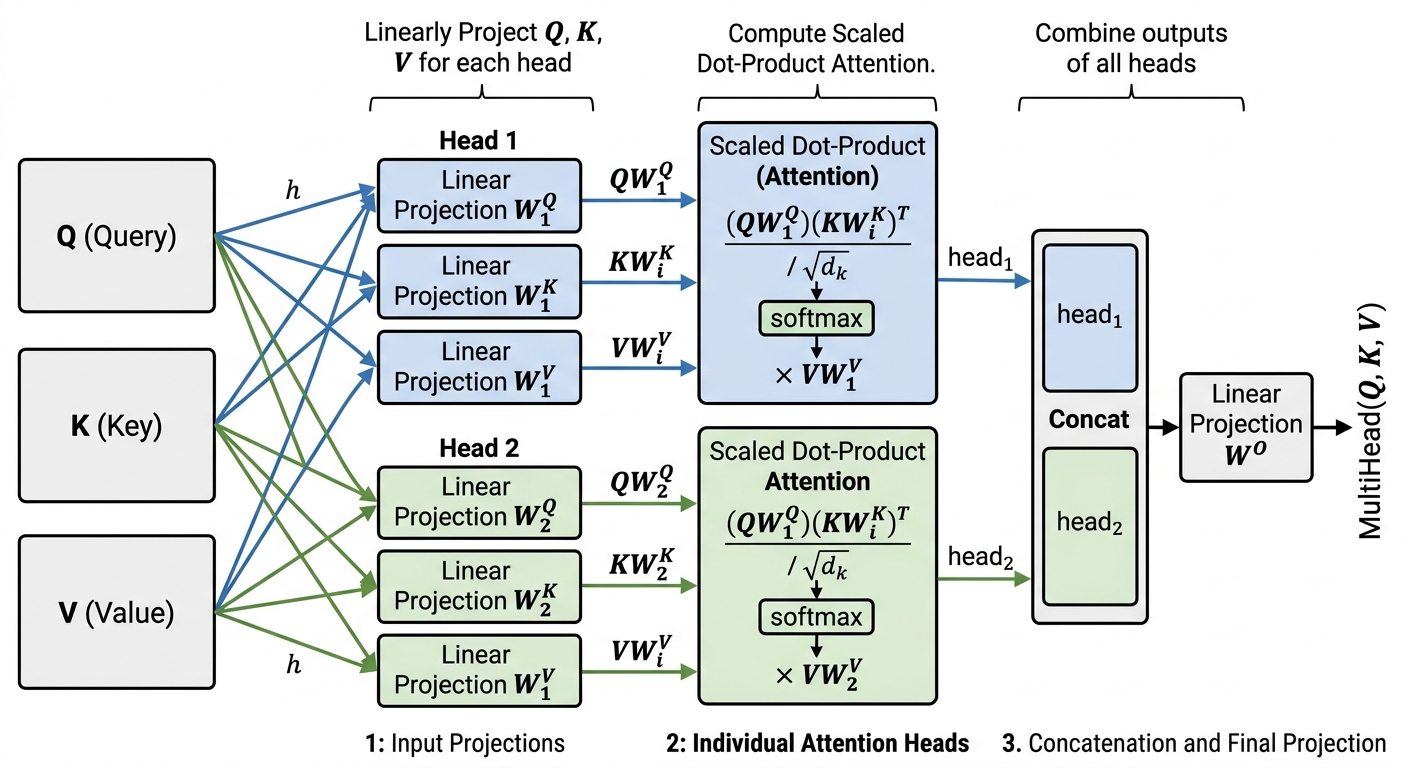

In [146]:
class MultiHeadedAttention(nn.Module):
    def __init__(self, h, d_model, dropout=0.1):
        "Take in model size and number of heads."
        super(MultiHeadedAttention, self).__init__()
        assert d_model % h == 0
        # We assume d_v always equals d_k
        self.d_k = d_model // h
        self.h = h
        self.linears = clones(nn.Linear(d_model, d_model), 4)
        self.attn = None
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, query, key, value, mask=None):
        "Implements Figure 2"
        if mask is not None:
            # Same mask applied to all h heads.
            mask = mask.unsqueeze(1)
        nbatches = query.size(0)

        # 1) Do all the linear projections in batch from d_model => h x d_k
        query, key, value = \
            [l(x).view(nbatches, -1, self.h, self.d_k).transpose(1, 2)
             for l, x in zip(self.linears, (query, key, value))]

        # 2) Apply attention on all the projected vectors in batch.
        x, self.attn = attention(query, key, value, mask=mask,
                                 dropout=self.dropout)

        # 3) "Concat" using a view and apply a final linear.
        x = x.transpose(1, 2).contiguous() \
             .view(nbatches, -1, self.h * self.d_k)
        return self.linears[-1](x)


# Different ways attention is applied in our Model

- [🎥 Video](https://youtu.be/rBCqOTEfxvg?si=H5ek5Rl_c0Hk9xX0&t=840)

The Transformer uses multi-head attention in three different ways:

- In “encoder-decoder attention” layers, the queries come from the previous decoder layer, and the memory keys and values come from the output of the encoder. This allows every position in the decoder to attend over all positions in the input sequence. This mimics the typical encoder-decoder attention mechanisms in sequence-to-sequence models.

- The encoder contains self-attention layers. In a self-attention layer all of the keys, values and queries come from the same place, in this case, the output of the previous layer in the encoder. Each position in the encoder can attend to all positions in the previous layer of the encoder.

- Similarly, self-attention layers in the decoder allow each position in the decoder to attend to all positions in the decoder up to and including that position. We need to prevent leftward information flow in the decoder to preserve the auto-regressive property. We implement this inside of scaled dot- product attention by masking out (setting to − ∞ ) all values in the input of the softmax which correspond to illegal connections.




### Simpler Summary: How Attention is Used in the Transformer

Multi-head attention is a versatile mechanism used in the Transformer model in three main ways, allowing the model to focus on different parts of the input and output sequences:

1.  **Encoder-Decoder Attention (Looking from Output to Input)**:
    *   **Purpose**: Allows the decoder to look at *all* parts of the encoder's output. This is how the model translates or generates text based on the entire input sequence.
    *   **How**: The 'query' comes from the current step in the decoder, and the 'keys' and 'values' come from the encoder's final output.

2.  **Encoder Self-Attention (Understanding the Input)**:
    *   **Purpose**: Helps the encoder understand the relationships between different words or tokens within the *input* sentence itself.
    *   **How**: All 'queries', 'keys', and 'values' come from the *same* previous layer of the encoder. Each word can look at every other word in the input.

3.  **Decoder Self-Attention (Generating Output Step-by-Step)**:
    *   **Purpose**: Allows the decoder to look at previously generated words in the *output* sentence to decide the next word, while preventing it from 'cheating' by looking at future words.
    *   **How**: All 'queries', 'keys', and 'values' come from the *same* previous layer of the decoder. A special 'mask' is applied to block information from future positions, ensuring the generation remains sequential.

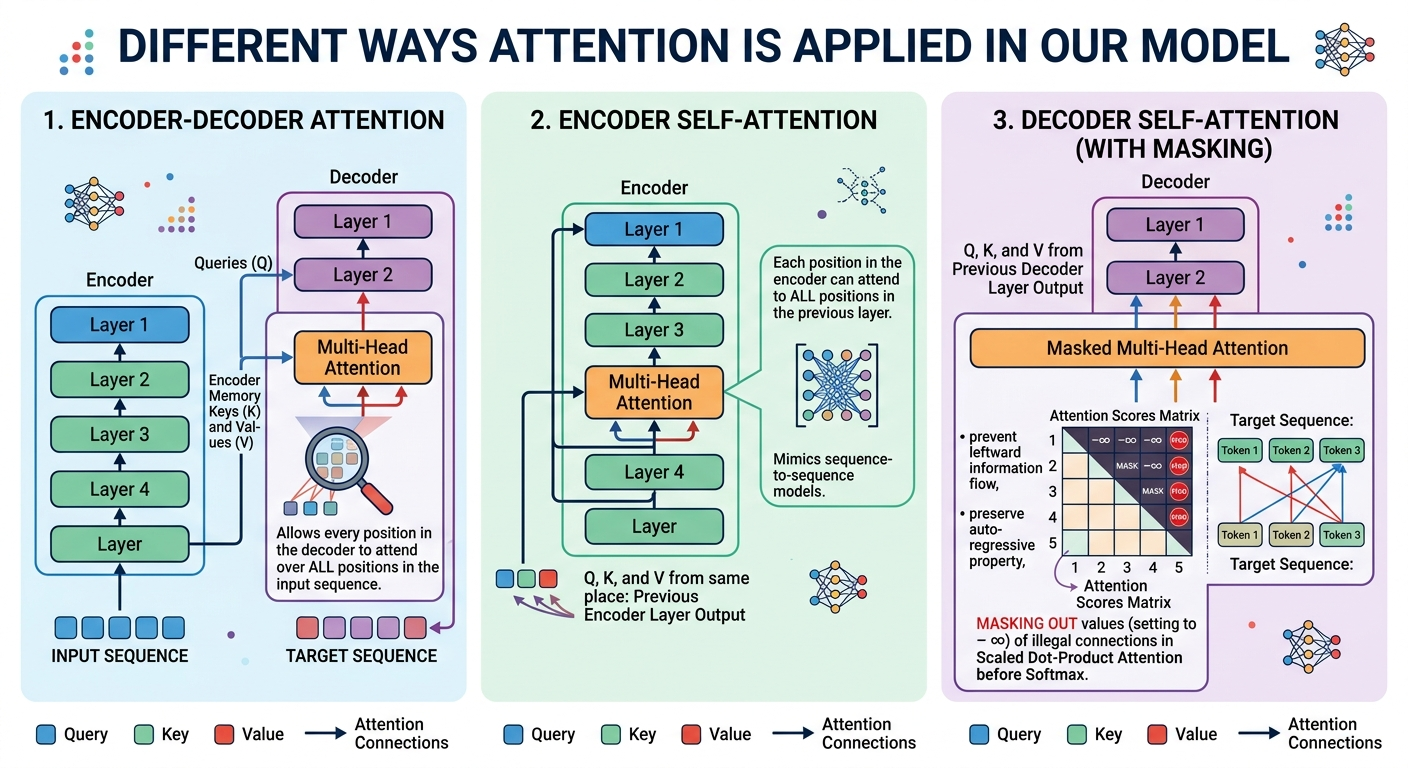

### Position-wise Feed-Forward Networks

In addition to the attention sub-layers, each layer within both the encoder and the decoder of the Transformer contains a **fully connected feed-forward network**. This network is applied to each position separately and identically, meaning the same network (with the same learned parameters) is used for every position in the sequence, though independently.

This feed-forward network consists of two linear transformations with a Rectified Linear Unit (ReLU) activation function applied in between them. The formula for this network is:

$$\text{FFN}(x) = \max(0, xW_1 + b_1)W_2 + b_2$$

Here's a breakdown of the components:

*   $x$: The input to the feed-forward network (typically the output from the attention sub-layer).
*   $W_1, b_1$: The weight matrix and bias vector for the first linear transformation.
*   $\max(0, \cdot)$: The ReLU activation function, which introduces non-linearity.
*   $W_2, b_2$: The weight matrix and bias vector for the second linear transformation.

While these linear transformations are applied identically across different positions within a single layer, it's important to note that *they use different parameters from layer to layer* (i.e., $W_1, b_1, W_2, b_2$ are unique for each encoder or decoder layer). Another way to conceptualize this is as two convolutions with a kernel size of 1, operating independently on each position.

**Dimensionality:**

*   The dimensionality of the input and output of the feed-forward network is $d_{\text{model}} = 512$.
*   The inner-layer (hidden layer after the first linear transformation and ReLU) has a higher dimensionality, $d_{\text{ff}} = 2048$. This expansion and then contraction of dimensions allows the network to process and transform the information at each position more effectively.

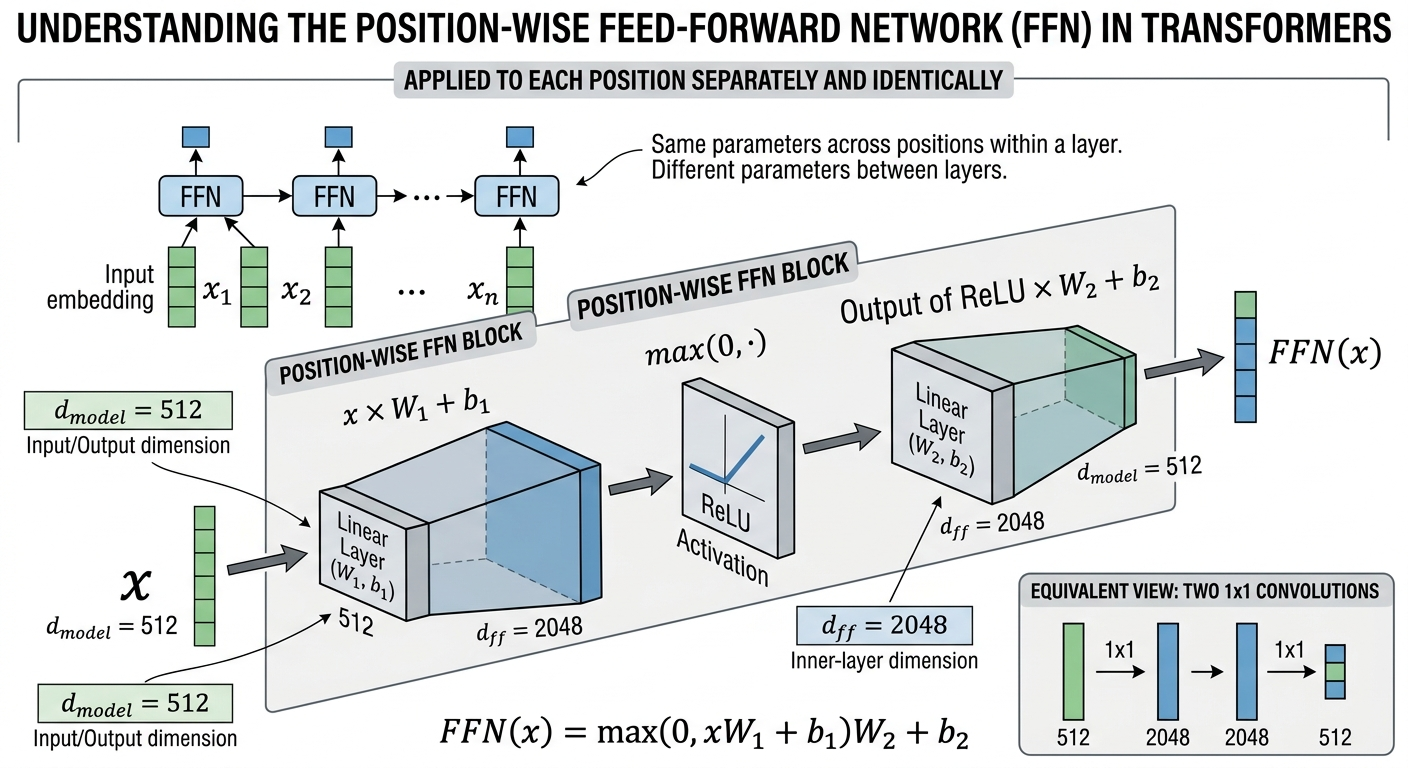

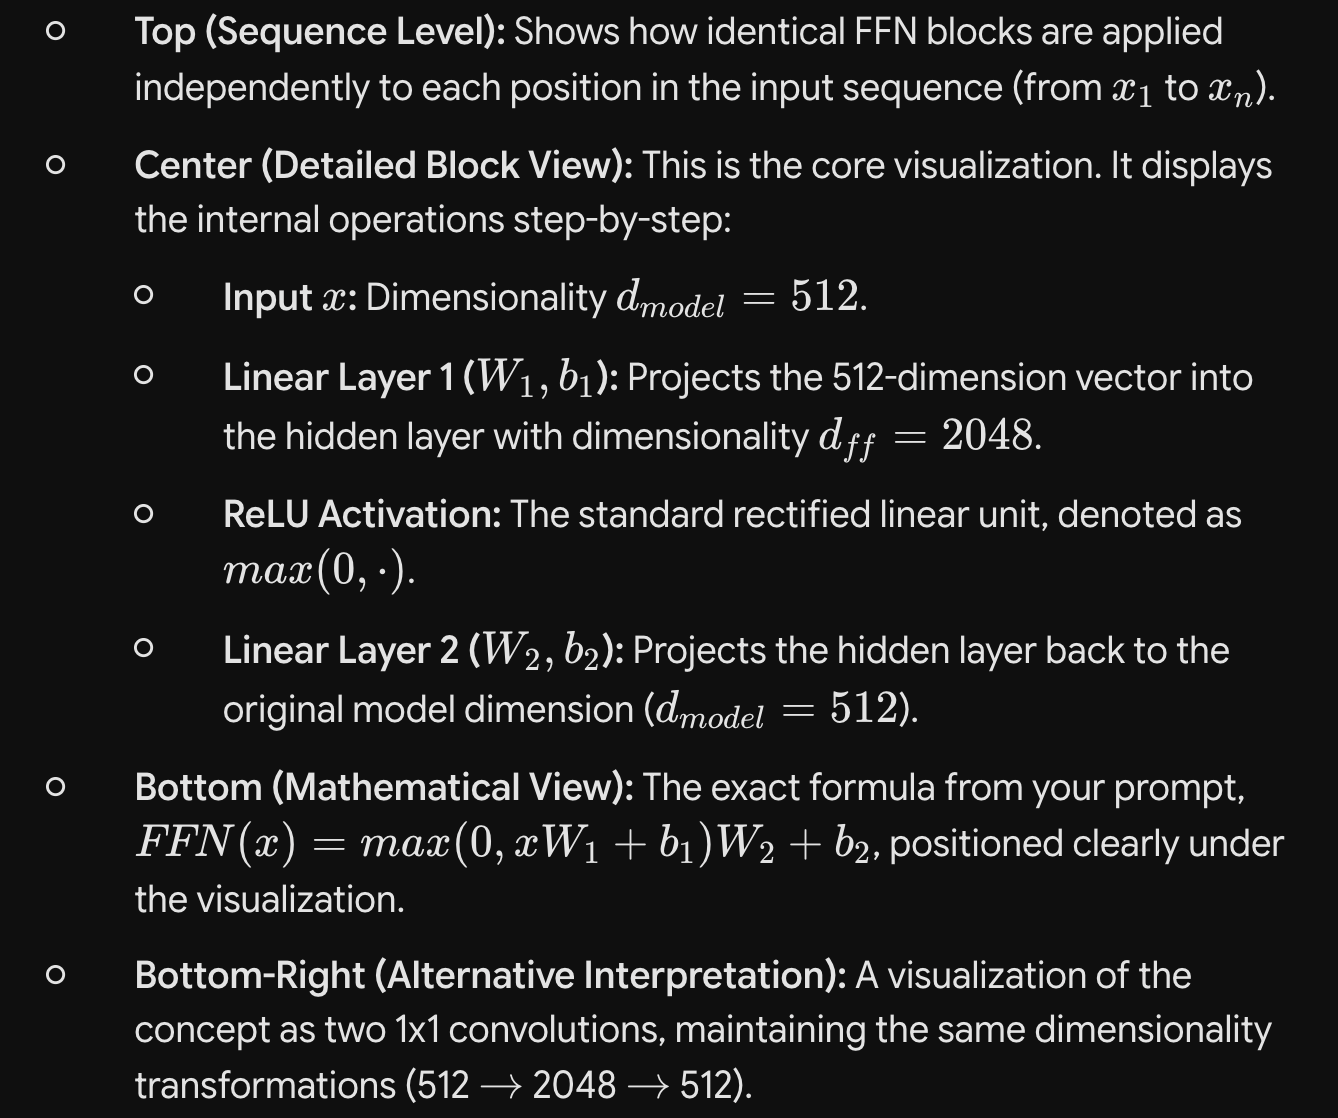

### What is ReLU (Rectified Linear Unit)?

ReLU, or Rectified Linear Unit, is a popular activation function used in artificial neural networks, especially in deep learning. Its primary role is to introduce non-linearity into the network, allowing it to learn more complex patterns in the data.

**Definition and Formula:**

The ReLU function is defined as:

$$\text{ReLU}(x) = \max(0, x)$$

This means:
*   If the input $x$ is positive, the output is $x$ itself.
*   If the input $x$ is zero or negative, the output is $0$.

Graphically, it looks like a hockey stick: flat at zero for negative values and then a linear ramp for positive values.

**Why is ReLU used?**

1.  **Non-linearity:** Without non-linear activation functions like ReLU, a neural network would essentially just be a series of linear transformations. This would mean that no matter how many layers you add, the network could only learn linear relationships, severely limiting its ability to model complex data.

2.  **Computational Efficiency:** Compared to other activation functions like sigmoid or tanh, ReLU is computationally very efficient. It only involves a simple comparison with zero and a simple multiplication (if $x>0$), making the forward and backward passes faster.

3.  **Mitigates Vanishing Gradient Problem:** Traditional activation functions like sigmoid or tanh suffer from the vanishing gradient problem, where gradients become very small for large positive or large negative inputs. This can slow down or stop the learning process in deep networks. ReLU, for positive inputs, has a constant gradient of 1, which helps in propagating gradients effectively through many layers.

4.  **Sparsity:** ReLU can lead to sparse activations. Since it outputs 0 for all negative inputs, a significant portion of neurons might be 'inactive' (outputting 0) for a given input. This sparsity can be beneficial, acting as a form of regularization and making the model more robust to noise.

# Position-Wise Feed-Forward Networks (FFN) in Transformers

## Overview

In addition to multi-head self-attention sub-layers, each layer of the Transformer encoder and decoder architecture contains a fully connected **position-wise feed-forward network (FFN)**.

The FFN is applied to each position (token) in the input sequence **separately and identically**. While the linear transformations remain identical across different token positions within a single layer, they utilize different weight parameters from layer to layer.

---

## Architectural Breakdown

The infographic organizes the position-wise Feed-Forward Network into four primary visual perspectives:

### 1. Sequence-Level Application (Position-Wise Processing)
* **Independent Execution:** The FFN acts on each token embedding ($x_1, x_2, \dots, x_n$) independently.
* **Shared Parameters:** The exact same weight matrices ($W_1, W_2$) and bias vectors ($b_1, b_2$) are applied across all positions within the same layer.
* **Layer Variance:** Different layers in the encoder/decoder stack maintain their own distinct parameter sets.

### 2. Detailed Internal Operations & Dimensionality
* **Input Vector ($x$):** Dimensionality of $d_{\text{model}} = 512$.
* **First Linear Layer ($W_1, b_1$):** Projects the 512-dimensional vector into an expanded hidden layer space of dimensionality $d_{\text{ff}} = 2048$.
* **ReLU Activation:** Applies element-wise non-linearity: $\max(0, \cdot)$.
* **Second Linear Layer ($W_2, b_2$):** Projects the expanded 2048-dimensional vector back down to the model's standard dimension ($d_{\text{model}} = 512$).

### 3. Mathematical Formulation
$$\text{FFN}(x) = \max(0, xW_1 + b_1)W_2 + b_2$$

Where:
* $x \in \mathbb{R}^{1 \times d_{\text{model}}}$ ($d_{\text{model}} = 512$)
* $W_1 \in \mathbb{R}^{d_{\text{model}} \times d_{\text{ff}}}$ ($512 \times 2048$)
* $b_1 \in \mathbb{R}^{d_{\text{ff}}}$ ($2048$)
* $W_2 \in \mathbb{R}^{d_{\text{ff}} \times d_{\text{model}}}$ ($2048 \times 512$)
* $b_2 \in \mathbb{R}^{d_{\text{model}}}$ ($512$)

### 4. Alternative Formulation: 1×1 Convolutions
* Another equivalent way to describe this network is as **two 1D convolutions with a kernel size of 1**.
* Channel transformations across layers: $512 \to 2048 \to 512$.
* This highlights that the transformation acts exclusively along the channel/feature dimension, without mixing information across sequence positions (unlike self-attention or larger convolutional kernels).


In [147]:
class PositionwiseFeedForward(nn.Module):
    "Implements FFN equation."
    def __init__(self, d_model, d_ff, dropout=0.1):
        super(PositionwiseFeedForward, self).__init__()
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.w_2(self.dropout(F.relu(self.w_1(x))))

### Line-by-Line Explanation of `PositionwiseFeedForward` Class

This code defines the `PositionwiseFeedForward` class, which implements the feed-forward network component of the Transformer model in PyTorch.

```python
class PositionwiseFeedForward(nn.Module):
    "Implements FFN equation."
    def __init__(self, d_model, d_ff, dropout=0.1):
        super(PositionwiseFeedForward, self).__init__()
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.w_2(self.dropout(F.relu(self.w_1(x))))
```

Let's break down each line:

1.  `class PositionwiseFeedForward(nn.Module):`
    *   **Explanation**: This line defines a new Python class named `PositionwiseFeedForward`. It inherits from `nn.Module`, which is the base class for all neural network modules in PyTorch. Inheriting from `nn.Module` provides core functionality like tracking parameters, submodules, and moving to different devices (CPU/GPU).

2.  `"Implements FFN equation."`
    *   **Explanation**: This is a docstring, providing a brief description of what the class does. It indicates that this class is designed to implement the Feed-Forward Network (FFN) equation as discussed previously.

3.  `def __init__(self, d_model, d_ff, dropout=0.1):`
    *   **Explanation**: This is the constructor method for the class. It's called when you create a new instance of `PositionwiseFeedForward`. It takes three arguments:
        *   `d_model`: The dimensionality of the input and output (e.g., 512 in the Transformer paper).
        *   `d_ff`: The dimensionality of the inner, hidden layer (e.g., 2048 in the Transformer paper).
        *   `dropout`: The dropout rate to apply for regularization (defaulting to 0.1).

4.  `super(PositionwiseFeedForward, self).__init__()`
    *   **Explanation**: This calls the constructor of the parent class (`nn.Module`). This is a standard Python practice when inheriting from a parent class to ensure proper initialization of the parent's attributes and methods.

5.  `self.w_1 = nn.Linear(d_model, d_ff)`
    *   **Explanation**: This line defines the first linear transformation layer. `nn.Linear` creates a module that applies a linear transformation to the input data using learned weights and biases ($xW_1 + b_1$).
        *   It takes an input of size `d_model` and produces an output of size `d_ff`.
        *   `self.w_1` becomes an attribute of the `PositionwiseFeedForward` instance.

6.  `self.w_2 = nn.Linear(d_ff, d_model)`
    *   **Explanation**: This defines the second linear transformation layer. It takes the output from the first layer (which has size `d_ff`) and transforms it back to the original `d_model` dimensionality ($xW_2 + b_2$ after the activation).
        *   `self.w_2` also becomes an attribute of the instance.

7.  `self.dropout = nn.Dropout(dropout)`
    *   **Explanation**: This initializes a dropout layer. `nn.Dropout` randomly sets a fraction (`dropout`) of the input features to zero during training. This is a regularization technique to prevent overfitting by making the network less reliant on specific neurons.

8.  `def forward(self, x):`
    *   **Explanation**: This method defines the forward pass of the module. It describes how the input `x` is processed through the network layers to produce an output. When you call an instance of `PositionwiseFeedForward` (e.g., `ffn_layer(input_tensor)`), this `forward` method is executed.

9. `return self.w_2(self.dropout(F.relu(self.w_1(x))))`
    *   **Explanation**: This is the core computation of the FFN, applying the sequence of operations:
        *   `self.w_1(x)`: Applies the first linear transformation to the input `x`.
        *   `F.relu(...)`: Applies the ReLU activation function (from `torch.nn.functional`) element-wise to the output of `self.w_1(x)`. This introduces non-linearity.
        *   `self.dropout(...)`: Applies dropout to the result of the ReLU activation.
        *   `self.w_2(...)`: Applies the second linear transformation to the output of the dropout layer.
    *   The final result is returned as the output of the `PositionwiseFeedForward` module.

### Positional Encoding in Transformers

- [🎥 Video from Stanford CME295 on positional encoding](https://youtu.be/yT84Y5zCnaA?si=ZErXp-EeJah_Ve7e&t=935)

- Since Transformer models completely eschew recurrence and convolution, they inherently lack any sense of sequence order. To enable the model to make use of the relative or absolute position of tokens within a sequence, we must inject this positional information.

- Achieved by adding **"positional encodings"** to the input embeddings at the bottom of both the encoder and decoder stacks. These positional encodings have the same dimension ($d_{\text{model}}$) as the token embeddings, allowing them to be simply summed together. There are various choices for positional encodings, including learned and fixed approaches.

### Sinusoidal Positional Encodings

In this work, we utilize a fixed scheme based on sine and cosine functions of different frequencies. The positional encoding for a given position `pos` and dimension `i` (where `i` refers to the index within the $d_{\text{model}}$ dimension) is calculated as follows:

$$\text{PE}_{(\text{pos}, 2i)} = \sin\left(\frac{\text{pos}}{10000^{2i/d_{\text{model}}}}\right)$$

$$\text{PE}_{(\text{pos}, 2i+1)} = \cos\left(\frac{\text{pos}}{10000^{2i/d_{\text{model}}}}\right)$$

*   `pos`: Represents the position of the token in the sequence (e.g., 0 for the first token, 1 for the second, etc.).
*   `i`: Represents the dimension within the embedding vector (ranging from $0$ to $d_{\text{model}}/2 - 1$ for `2i` and $0$ to $d_{\text{model}}/2 - 1$ for `2i+1`).

This means that each dimension of the positional encoding corresponds to a sinusoid. The wavelengths of these sinusoids form a geometric progression from $2\pi$ to $10000 \cdot 2\pi$. This specific choice of function was made because it allows for easy representation of relative positions: for any fixed offset $k$, $\text{PE}_{\text{pos}+k}$ can be expressed as a linear function of $\text{PE}_{\text{pos}}$. This property is crucial for the model to effectively learn and utilize relative positional information.

### Dropout Application

To further regularize the model and prevent overfitting, dropout is applied to the sum of the embeddings and the positional encodings in both the encoder and decoder stacks. For the base model, a dropout rate of $P_{\text{drop}} = 0.1$ is used.

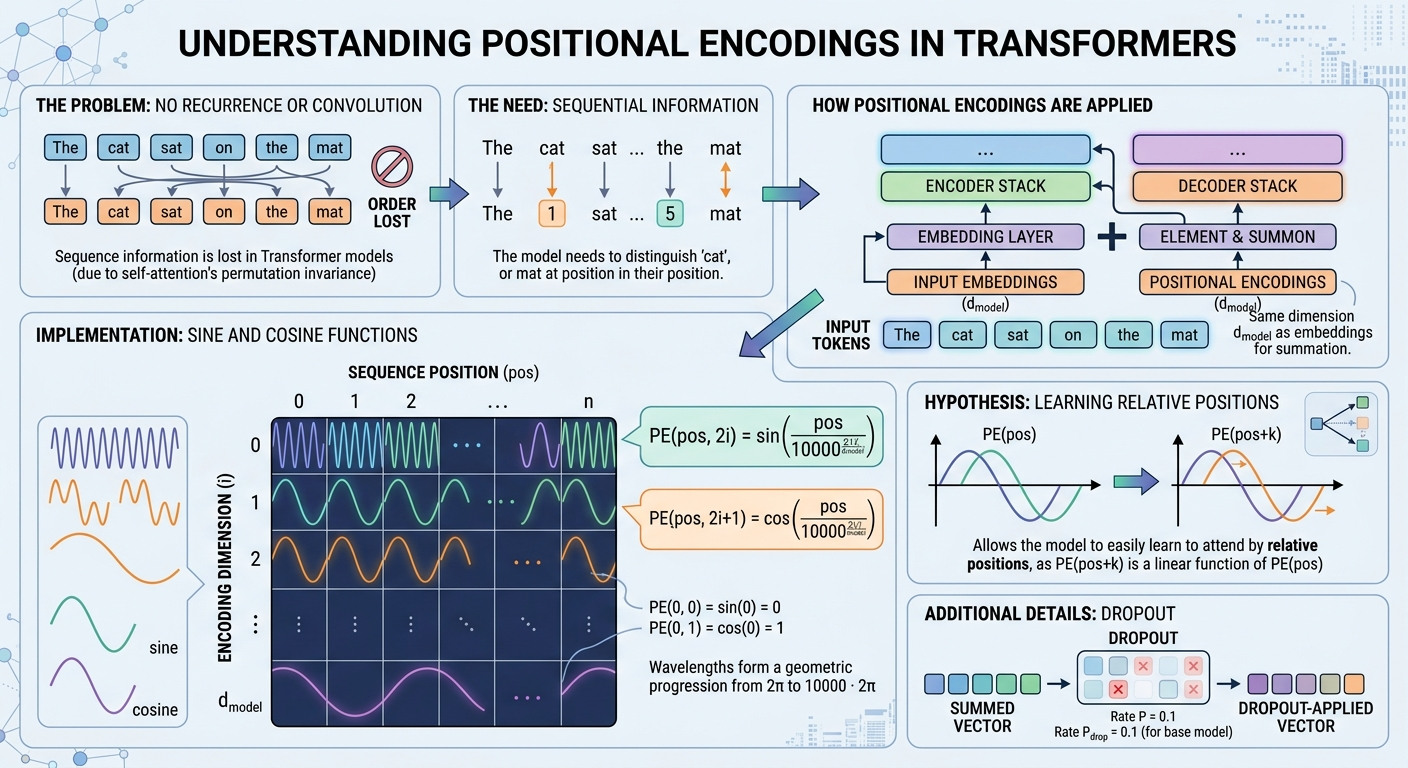

In [148]:
class PositionalEncoding(nn.Module):
    "Implement the PE function."
    def __init__(self, d_model, dropout, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Compute the positional encodings once in log space.
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) *
                             -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + Variable(self.pe[:, :x.size(1)],
                         requires_grad=False)
        return self.dropout(x)


### Line-by-Line Explanation of `PositionalEncoding` Class

This code defines the `PositionalEncoding` class, which implements the positional encoding mechanism for Transformer models in PyTorch. Positional encodings are crucial for injecting information about the absolute or relative position of tokens in a sequence, as Transformers do not inherently process sequence order.

```python
class PositionalEncoding(nn.Module):
    "Implement the PE function."
    def __init__(self, d_model, dropout, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        # Compute the positional encodings once in log space.
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) *
                             -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        x = x + Variable(self.pe[:, :x.size(1)],
                         requires_grad=False)
        return self.dropout(x)
```

Let's break down each line:

1.  `class PositionalEncoding(nn.Module):`
    *   **Explanation**: This line defines the `PositionalEncoding` class, inheriting from `nn.Module`. This makes it a standard PyTorch module, allowing it to manage parameters (though positional encodings are fixed, not learned), submodules, and integrate into larger neural networks.

2.  `"Implement the PE function."`
    *   **Explanation**: This is a docstring, providing a brief description that the class implements the Positional Encoding (PE) function.

3.  `def __init__(self, d_model, dropout, max_len=5000):`
    *   **Explanation**: This is the constructor. It initializes an instance of `PositionalEncoding` and takes the following arguments:
        *   `d_model`: The dimension of the model's embeddings (e.g., 512). This is also the dimension of the positional encoding vectors.
        *   `dropout`: The dropout rate to apply to the output of the positional encoding layer.
        *   `max_len`: The maximum sequence length for which to pre-compute positional encodings (defaulting to 5000). This pre-computation makes the encoding process efficient during inference.

4.  `super(PositionalEncoding, self).__init__()`
    *   **Explanation**: Calls the constructor of the parent class `nn.Module`, ensuring proper initialization of PyTorch module functionalities.

5.  `self.dropout = nn.Dropout(p=dropout)`
    *   **Explanation**: Initializes a dropout layer with the specified `dropout` rate. This dropout will be applied to the sum of the input embeddings and the positional encodings, as a regularization technique.

6.  `pe = torch.zeros(max_len, d_model)`
    *   **Explanation**: Creates an empty tensor named `pe` (positional encoding) of shape `(max_len, d_model)`. This tensor will store the pre-computed positional encodings.

7.  `position = torch.arange(0, max_len).unsqueeze(1)`
    *   **Explanation**: Creates a tensor `position` that contains integers from `0` to `max_len - 1`. Each integer represents a position in the sequence. `unsqueeze(1)` changes its shape from `(max_len,)` to `(max_len, 1)`, making it suitable for element-wise multiplication with `div_term` later.

8.  `div_term = torch.exp(torch.arange(0, d_model, 2) * -(math.log(10000.0) / d_model))`
    *   **Explanation**: This line calculates the `div_term` part of the positional encoding formula: $1 / (10000^{2i/d_{	ext{model}}})$.
        *   `torch.arange(0, d_model, 2)`: Creates a tensor with even indices `0, 2, 4, ..., d_model-2`. These correspond to `2i` in the formula.
        *   `-(math.log(10000.0) / d_model)`: Calculates `log(1/10000^(1/d_model))` which simplifies to `-log(10000) / d_model`. This is multiplied by `2i` (from `torch.arange(..., 2)`) in the exponent to compute the inverse frequency term.
        *   `torch.exp(...)`: Applies the exponential function to get $e^{	ext{term}}$, which effectively computes $10000^{-(2i/d_{	ext{model}})}$. This term will be broadcast across positions and used to create different wavelengths for the sine/cosine waves.

9.  `pe[:, 0::2] = torch.sin(position * div_term)`
    *   **Explanation**: Fills the even-indexed dimensions (`0, 2, 4, ...`) of the `pe` tensor with sine values. It computes `sin(pos / (10000^(2i/d_model)))` for all positions and even dimensions `2i`.

10. `pe[:, 1::2] = torch.cos(position * div_term)`
    *   **Explanation**: Fills the odd-indexed dimensions (`1, 3, 5, ...`) of the `pe` tensor with cosine values. It computes `cos(pos / (10000^(2i/d_model)))` for all positions and odd dimensions `2i+1`.

11. `pe = pe.unsqueeze(0)`
    *   **Explanation**: Adds an extra dimension at the beginning of the `pe` tensor, changing its shape from `(max_len, d_model)` to `(1, max_len, d_model)`. This is done to make `pe` compatible with batch processing (the first dimension often represents the batch size), allowing it to be broadcast correctly when added to input embeddings `x`.

12. `self.register_buffer('pe', pe)`
    *   **Explanation**: Registers `pe` as a buffer. Buffers are stateful tensors that are not considered model parameters (they don't require gradients and are not updated by the optimizer), but they are part of the module's state and are moved to the correct device (CPU/GPU) along with the module. This ensures that the pre-computed positional encodings are saved and loaded correctly with the model.

13. `def forward(self, x):`
    *   **Explanation**: This method defines the forward pass of the positional encoding module. It describes how input embeddings `x` are combined with positional encodings.

14. `x = x + Variable(self.pe[:, :x.size(1)], requires_grad=False)`
    *   **Explanation**: This is where the positional encoding is added to the input embeddings `x`.
        *   `self.pe[:, :x.size(1)]`: Selects the relevant part of the pre-computed `pe` buffer based on the current sequence length of `x` (i.e., `x.size(1)`). This ensures that only encodings for the actual sequence length are used.
        *   `Variable(...)`: In older PyTorch versions, `Variable` was used to wrap tensors that required gradient computation. While it's largely deprecated in newer PyTorch versions (tensors themselves track `requires_grad`), its use here explicitly marks the positional encoding as not requiring gradients (`requires_grad=False`), reinforcing that `pe` is a fixed, non-trainable component.
        *   `x + ...`: Element-wise addition of the positional encodings to the input embeddings `x`. This operation injects the positional information into the token representations.

15. `return self.dropout(x)`
    *   **Explanation**: Applies dropout to the combined embeddings and positional encodings, and then returns the result. This helps to prevent overfitting by randomly setting some elements to zero.

# Plots for positional encoding

Below the positional encoding will add in a sine wave based on position. The frequency and offset of the wave is different for each dimension.



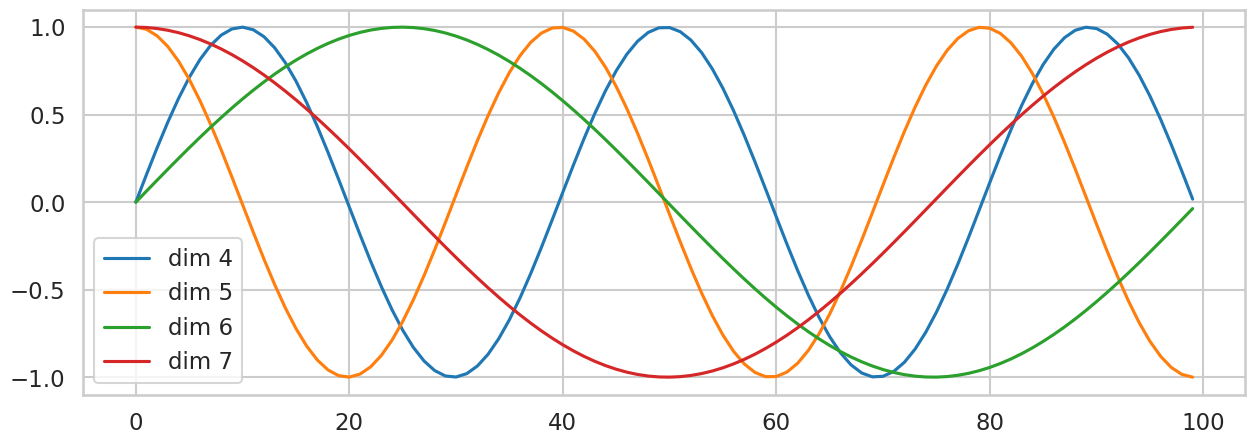

In [149]:
plt.figure(figsize=(15, 5))
pe = PositionalEncoding(20, 0)
y = pe.forward(Variable(torch.zeros(1, 100, 20)))
plt.plot(np.arange(100), y[0, :, 4:8].data.numpy())
plt.legend(["dim %d"%p for p in [4,5,6,7]])


### 🤔 ❓ Challenge Exercise: Implement an Alternative Positional Encoding

The sinusoidal positional encodings used in the Transformer are quite effective due to their ability to represent relative positions. However, other fixed or even learnable positional encoding schemes exist.

**Challenge:** Implement a simpler, alternative fixed positional encoding. For this exercise, let's consider a **linear positional encoding**, where each position `pos` is mapped directly to a vector of linearly increasing values across its dimensions, or a combination of linearly increasing values and a simpler periodic function.

Your task is to complete the `PositionalEncodingLinear` class below. Consider how its properties might differ from the sinusoidal encodings, particularly regarding its ability to generalize to longer sequences or represent relative positions.

**Hints:**
*   Instead of sine and cosine, you might use a linear sequence `torch.linspace` or `torch.arange` for `pos` and `i` combinations.
*   Think about how you would scale these values to keep them in a reasonable range relative to the embeddings.
*   You still need to handle `d_model`, `dropout`, and `max_len`.
*   The `forward` method should still add this `pe` to the input `x` and apply dropout.

In [150]:
class PositionalEncodingLinear(nn.Module):
    "Implement a linear positional encoding as a challenge."
    def __init__(self, d_model, dropout, max_len=5000):
        super(PositionalEncodingLinear, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        # --- STUDENT CHALLENGE START ---
        # Task: Compute the positional encodings using a linear scheme.
        # Example: pe[pos, i] = (pos + i) / d_model or similar.
        # The goal is to generate unique, fixed vectors for each position.
        pe = torch.zeros(max_len, d_model)

        # Suggested implementation for linear encoding:
        position = torch.arange(0, max_len).unsqueeze(1)
        dimension_scale = torch.arange(0, d_model).unsqueeze(0) / d_model # Scale dimensions

        # A simple linear combination (can be improved/modified by students)
        pe = (position + dimension_scale) / max_len # Normalize by max_len for stability

        # --- STUDENT CHALLENGE END ---

        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # Ensure 'Variable' is imported from torch.autograd if needed for older PyTorch versions.
        # x = x + Variable(self.pe[:, :x.size(1)], requires_grad=False)

        # For modern PyTorch, direct tensor addition is fine
        x = x + self.pe[:, :x.size(1)].detach() # .detach() explicitly removes from graph
        return self.dropout(x)

# Example of how students might test it:
# d_model_test = 512
# dropout_test = 0.1
# max_len_test = 100
# linear_pe_layer = PositionalEncodingLinear(d_model_test, dropout_test, max_len_test)
# dummy_input = torch.randn(1, 50, d_model_test) # batch_size=1, seq_len=50
# output = linear_pe_layer(dummy_input)
# print(f"Output shape: {output.shape}")
# print(f"First 5 positional encoding vectors:\n{linear_pe_layer.pe[0, :5, :]}")

### Solution

In [151]:
import torch.nn as nn
import torch

class PositionalEncodingLinearSolution(nn.Module):
    "Solution for implementing a linear positional encoding."
    def __init__(self, d_model, dropout, max_len=5000):
        super(PositionalEncodingLinearSolution, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1) # Shape: (max_len, 1)

        # Create a linear progression across the feature dimensions for each position
        # Example: For d_model=4, this might be [[0, 1, 2, 3], [0, 1, 2, 3], ...]
        dimension_factors = torch.arange(0, d_model).unsqueeze(0) # Shape: (1, d_model)

        # Combine position and dimension factors linearly
        # A simple additive combination, normalized to keep values small
        # This ensures unique encoding for each (pos, dim) pair
        pe = (position + dimension_factors) / max_len # Normalize by max_len for values between 0 and ~1

        # You could also try other simple linear or piecewise functions:
        # pe = position * (dimension_factors / d_model) # More direct product relationship
        # pe = (position % 10) / 10.0 + (dimension_factors / d_model) # Adding a periodic component

        pe = pe.unsqueeze(0) # Add batch dimension: (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # Add positional encoding to input embeddings
        # .detach() ensures no gradients are computed for the positional encoding itself
        x = x + self.pe[:, :x.size(1)].detach()
        return self.dropout(x)

# --- Demonstration of the Linear Positional Encoding Solution ---

print("Demonstrating PositionalEncodingLinearSolution:")

d_model_test = 512
dropout_test = 0.1
max_len_test = 100

# Instantiate the solution class
linear_pe_solution_layer = PositionalEncodingLinearSolution(d_model_test, dropout_test, max_len_test)

# Create a dummy input batch (batch_size, sequence_length, d_model)
dummy_input = torch.randn(2, 50, d_model_test) # 2 sentences, each 50 tokens long

# Apply the positional encoding
output_with_pe = linear_pe_solution_layer(dummy_input)

print(f"Original input shape: {dummy_input.shape}")
print(f"Output shape after applying PE: {output_with_pe.shape}")

print("\nFirst 5 positional encoding vectors (from pe buffer, 0th batch, first 5 positions):")
print(linear_pe_solution_layer.pe[0, :5, :8]) # Print first 8 dimensions for brevity

print("\nVerifying addition: Does output - input = pe for first element?")
# For verification, we need to compare before and after dropout application
# Let's assume for this check we don't apply dropout in this specific comparison
pe_applied_to_input = dummy_input[0, 0, :8] + linear_pe_solution_layer.pe[0, 0, :8].detach()
print(f"Input[0,0,:8]: {dummy_input[0, 0, :8].round(decimals=4)}")
print(f"PE[0,0,:8]:   {linear_pe_solution_layer.pe[0, 0, :8].detach().round(decimals=4)}")
# Since dropout is applied, we can't directly verify output_with_pe - dummy_input
# But we can see the pe values themselves.


Demonstrating PositionalEncodingLinearSolution:
Original input shape: torch.Size([2, 50, 512])
Output shape after applying PE: torch.Size([2, 50, 512])

First 5 positional encoding vectors (from pe buffer, 0th batch, first 5 positions):
tensor([[0.0000, 0.0100, 0.0200, 0.0300, 0.0400, 0.0500, 0.0600, 0.0700],
        [0.0100, 0.0200, 0.0300, 0.0400, 0.0500, 0.0600, 0.0700, 0.0800],
        [0.0200, 0.0300, 0.0400, 0.0500, 0.0600, 0.0700, 0.0800, 0.0900],
        [0.0300, 0.0400, 0.0500, 0.0600, 0.0700, 0.0800, 0.0900, 0.1000],
        [0.0400, 0.0500, 0.0600, 0.0700, 0.0800, 0.0900, 0.1000, 0.1100]])

Verifying addition: Does output - input = pe for first element?
Input[0,0,:8]: tensor([-0.1525, -0.5190,  0.8986, -0.9874,  0.2069,  1.3535, -0.8974, -1.1451])
PE[0,0,:8]:   tensor([0.0000, 0.0100, 0.0200, 0.0300, 0.0400, 0.0500, 0.0600, 0.0700])


### 🤔 ❓ Challenge Question: The Role of `d_model` and `d_ff` in Position-wise Feed-Forward Networks

Recall the structure of the `PositionwiseFeedForward` network, which processes each token's representation independently within the Transformer's encoder and decoder layers.

**Question:**
1.  **Explain the significance of the `d_model` and `d_ff` parameters within the `PositionwiseFeedForward` network.** What do these dimensions represent, and why are they typically set to values like `d_model = 512` and `d_ff = 2048` in the original Transformer architecture?
2.  **Elaborate on the purpose of the FFN's internal structure:** why does it first project the input from `d_model` to a larger `d_ff` dimension, and then project it back down to `d_model`?
3.  **Consider a hypothetical scenario:** What would be the potential **computational** and **representational** implications if `d_ff` were chosen to be equal to `d_model` (i.e., no expansion and contraction in dimensionality)? Would the network still be able to learn effectively, and what might be lost or gained?

# Full model

- a function that takes in hyperparameters and produces a full model

In [152]:
class Embeddings(nn.Module):
    def __init__(self, d_model, vocab):
        super(Embeddings, self).__init__()
        self.lut = nn.Embedding(vocab, d_model)
        self.d_model = d_model

    def forward(self, x):
        return self.lut(x) * math.sqrt(self.d_model)

def make_model(src_vocab, tgt_vocab, N=6,
               d_model=512, d_ff=2048, h=8, dropout=0.1):
    "Helper: Construct a model from hyperparameters."
    c = copy.deepcopy
    attn = MultiHeadedAttention(h, d_model)
    ff = PositionwiseFeedForward(d_model, d_ff, dropout)
    position = PositionalEncoding(d_model, dropout)
    model = EncoderDecoder(
        Encoder(EncoderLayer(d_model, c(attn), c(ff), dropout), N),
        Decoder(DecoderLayer(d_model, c(attn), c(attn),
                             c(ff), dropout), N),
        nn.Sequential(Embeddings(d_model, src_vocab), c(position)),
        nn.Sequential(Embeddings(d_model, tgt_vocab), c(position)),
        Generator(d_model, tgt_vocab))

    # This was important from their code.
    # Initialize parameters with Glorot / fan_avg.
    for p in model.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)
    return model



# Small example model.
tmp_model = make_model(src_vocab = 10,
                       tgt_vocab = 10,
                       N = 2)

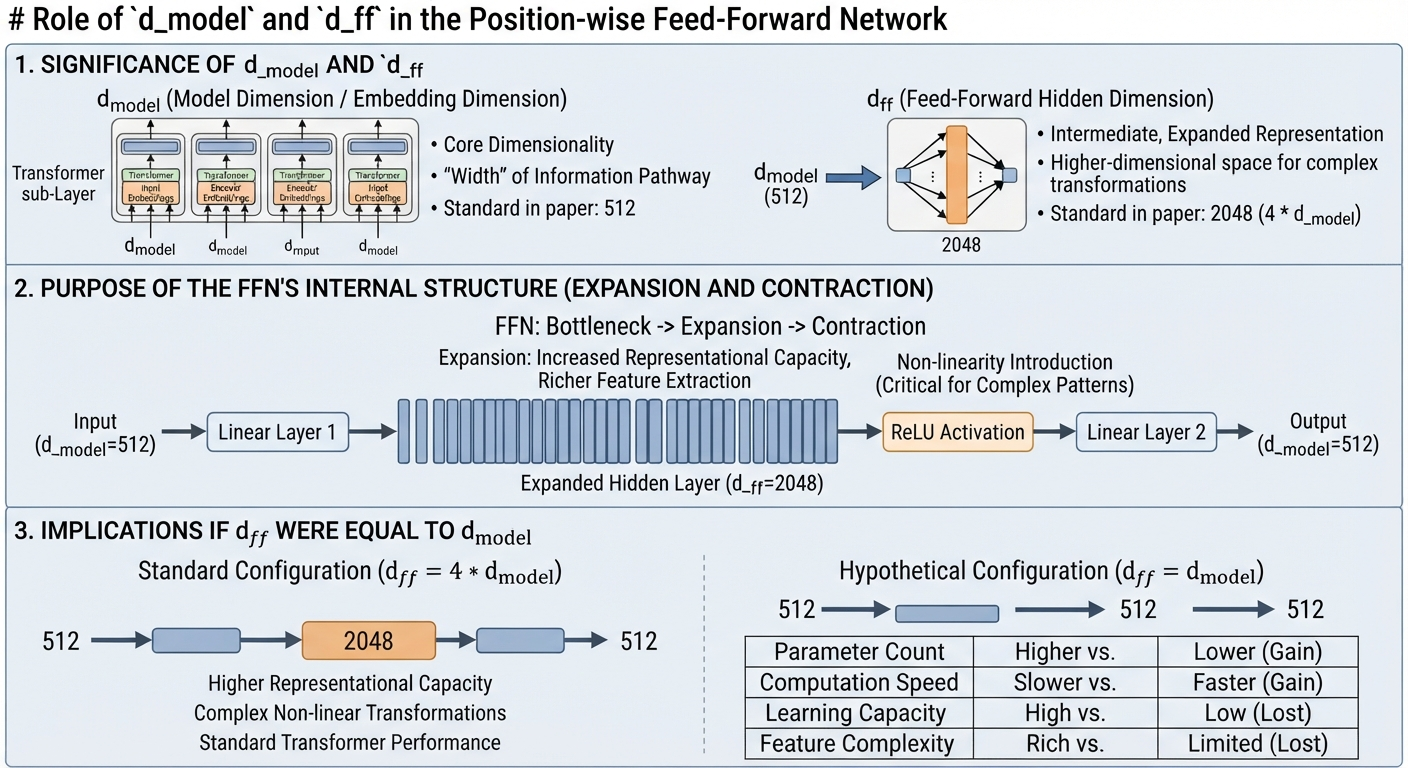

# Role of `d_model` and `d_ff` in the Position-wise Feed-Forward Network:

**1. Significance of `d_model` and `d_ff`:**

*   **`d_model` (Model Dimension/Embedding Dimension):**
    *   `d_model` represents the dimensionality of the input and output tensors for *each sub-layer* in the Transformer, including the input embeddings, positional encodings, and the output of the encoder and decoder. It is the core dimension of the model's representations. Think of it as the 'width' of the information pathway throughout the network. In the original Transformer paper, `d_model` is typically 512.
    *   Its significance lies in maintaining a consistent representational capacity across different layers and sub-layers, allowing for residual connections (where outputs and inputs can be easily added) and ensuring that information can be processed uniformly.

*   **`d_ff` (Feed-Forward Hidden Dimension):**
    *   `d_ff` is the dimensionality of the *hidden layer* within the Position-wise Feed-Forward Network. This layer is an intermediate, expanded representation space. In the original Transformer paper, `d_ff` is typically 2048, which is 4 times `d_model`.
    *   Its significance is to provide a higher-dimensional space where the model can perform more complex transformations and learn richer features from the input representation at each position. This expansion allows the network to process and transform the information at each position more effectively.

**2. Purpose of the FFN's Internal Structure (Expansion and Contraction):**

The FFN first projects the input from `d_model` to a larger `d_ff` dimension, applies an activation function (ReLU), and then projects it back down to `d_model`. This expansion and contraction serve several key purposes:

*   **Increased Representational Capacity:** The higher-dimensional `d_ff` space allows the network to capture more intricate and non-linear relationships within the features of each token. It provides a 'bottleneck' followed by an expansion, similar to what's seen in autoencoders or certain convolutional network blocks, enabling richer feature extraction.
*   **Non-linearity:** The ReLU activation function applied in the expanded space introduces critical non-linearity. Without this, the entire Transformer (composed only of linear projections and sums) would essentially be a linear model, severely limiting its ability to learn complex patterns in language.
*   **Information Transformation:** It allows the model to transform the representation of each token independently. While attention mechanisms allow tokens to interact, the FFN allows for individual token processing and feature refinement based on their current context-aware representation.

**3. Implications if `d_ff` were equal to `d_model`:**

If `d_ff` were chosen to be equal to `d_model` (e.g., `d_ff = 512` instead of `2048`), the implications would be significant for both computational efficiency and representational power:

*   **Representational Implications (What might be lost/gained):**
    *   **Loss of Expressive Power:** The primary loss would be in the model's capacity to learn complex, non-linear transformations. The FFN would essentially become two sequential linear layers with an activation in between, operating within the same dimensionality. This reduced dimensionality for internal processing would likely make it harder for the network to extract rich, higher-level features for each token. The model might struggle to learn intricate patterns necessary for tasks like language understanding or translation.
    *   **Less Feature Engineering:** The expansion to a larger `d_ff` allows for a richer internal feature space. Without this, the model has fewer 'intermediate features' to play with, potentially limiting its ability to make fine-grained adjustments to the token representations.

*   **Computational Implications (What might be lost/gained):**
    *   **Reduced Parameters (Gained):** There would be fewer parameters in the `PositionwiseFeedForward` layer. For example, if `d_model=512` and `d_ff=2048`, the first linear layer has `512 * 2048` parameters and the second has `2048 * 512`. If `d_ff=d_model=512`, both layers would have `512 * 512` parameters. This would lead to a smaller model size.
    *   **Faster Computation (Gained):** With fewer parameters and smaller matrix multiplications, the FFN layers would execute faster, potentially leading to quicker training and inference times.
    *   **Potential Underfitting (Lost):** While faster, the reduced representational power could lead to underfitting, where the model is too simple to capture the underlying patterns in the data, resulting in lower performance on complex tasks.

In summary, while setting `d_ff = d_model` would make the model smaller and faster, it would likely come at the cost of significantly reduced learning capacity and model performance for tasks that require deep, complex feature transformations like those handled by Transformers.

# Acknowledgements and declaration on generative AI use

This is inspired and adapted from [The Annotated Transformer, Harvard](https://nlp.seas.harvard.edu/2018/04/03/attention.html). Parts of the text and images are copied from that resource or generated using AI. I make no claims to originality. All material belongs to the respective creators. This is made for educational purposes only.

# References

- [Annotated Transformer](https://nlp.seas.harvard.edu/2018/04/03/attention.html)
- [Illustrated Transformer by Jay Alammar](https://jalammar.github.io/illustrated-transformer/)
- [🎥Transformers video by Grant Sanderson _3blue1brown_](https://www.youtube.com/watch?v=KJtZARuO3JY&t=177s)
- [Transformer tutorial by `Tensorflow` and _Francois Chollet_](https://www.tensorflow.org/text/tutorials/transformer)